# Data Processing — Part 2

This notebook continues from **Data Processing — Part 1**.

Before running this notebook, run Part 1 first. Part 1 creates and saves:

- `data/processed/inputs_after_cleaning.csv`
- `data/processed/target_after_cleaning.csv`

In this notebook, we load those files and continue with WoE/IV analysis, dummy grouping, continuous variable classing, and final train/test export.


## Import required libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load processed data from Part 1

In [3]:
os.getcwd()

'c:\\Users\\k\\Credit_Risk_Model\\data_preparation'

In [4]:
os.chdir("..")

In [5]:
os.getcwd()

'c:\\Users\\k\\Credit_Risk_Model'

In [6]:
# Load the processed input variables and target variable saved in Part 1.
X = pd.read_csv("data/processed/inputs_after_cleaning.csv")
y = pd.read_csv("data/processed/target_after_cleaning.csv").squeeze("columns")

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

C:\Users\k\AppData\Local\Temp\ipykernel_16576\504710142.py:2: DtypeWarning: Columns (0: desc, 1: next_pymnt_d) have mixed types. Specify dtype option on import or set low_memory=False.
  X = pd.read_csv("data/processed/inputs_after_cleaning.csv")


X shape: (466285, 198)
y shape: (466285,)
good_bad
1    415317
0     50968
Name: count, dtype: int64


## Data Preparation

In [7]:
df_inputs_prepr = X
df_targets_prepr = y

In [8]:
df_inputs_prepr['grade'].unique()

<StringArray>
['B', 'C', 'A', 'E', 'F', 'D', 'G']
Length: 7, dtype: str

In [9]:
df1 = pd.concat([df_inputs_prepr['grade'], df_targets_prepr], axis=1)

df1.head()

,grade,good_bad
0,B,1
1,C,0
2,C,1
3,C,1
4,B,1


In [10]:
df1.columns.values[0]


'grade'

#### **grade** column
It shows how risky the borrower is considered to be.                                                                                                         
A = lowest risk / best credit quality                                                                                                                              
B = low risk                                                                                                              
C = medium risk                                                                                                           
D = higher risk                                                                                                           
E = high risk                                                                                                             
F = very high risk                                                                                                            
G = highest risk / riskiest borrowers                                                                                                             

In [11]:
# Counts the number of observations in each category of the first column.
df1.groupby('grade')['good_bad'].count()

grade
A     74867
B    136929
C    125293
D     76888
E     35757
F     13229
G      3322
Name: good_bad, dtype: int64

In [12]:
# Calculates the proportion of good borrowers in each credit grade.
df1.groupby("grade")['good_bad'].mean()

grade
A    0.961305
B    0.921426
C    0.885197
D    0.845906
E    0.805241
F    0.758712
G    0.721854
Name: good_bad, dtype: float64

In [13]:
df1 = pd.concat([df1.groupby(df1.columns.values[0], as_index = False)[df1.columns.values[1]].count(),
                df1.groupby(df1.columns.values[0], as_index = False)[df1.columns.values[1]].mean()], axis = 1)

In [14]:
df1 = df1.iloc[:, [0, 1, 3]]
df1

,grade,good_bad,good_bad
0,A,74867,0.961305
1,B,136929,0.921426
2,C,125293,0.885197
3,D,76888,0.845906
4,E,35757,0.805241
5,F,13229,0.758712
6,G,3322,0.721854


In [15]:
df1.columns = [df1.columns.values[0], 'n_obs', 'prop_good']

df1

,grade,n_obs,prop_good
0,A,74867,0.961305
1,B,136929,0.921426
2,C,125293,0.885197
3,D,76888,0.845906
4,E,35757,0.805241
5,F,13229,0.758712
6,G,3322,0.721854


In [16]:
# Calculates the proportion of total observations that belong to each category.
df1['prop_n_obs'] = df1['n_obs'] / df1['n_obs'].sum()

df1

,grade,n_obs,prop_good,prop_n_obs
0,A,74867,0.961305,0.160561
1,B,136929,0.921426,0.293659
2,C,125293,0.885197,0.268705
3,D,76888,0.845906,0.164895
4,E,35757,0.805241,0.076685
5,F,13229,0.758712,0.028371
6,G,3322,0.721854,0.007124


In [17]:
# Calculates the number of good borrowers in each category.
df1['n_good'] = df1['prop_good'] * df1['n_obs']

# Calculates the number of bad borrowers in each category.
df1['n_bad'] = (1 - df1['prop_good']) * df1['n_obs']

df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad
0,A,74867,0.961305,0.160561,71970.0,2897.0
1,B,136929,0.921426,0.293659,126170.0,10759.0
2,C,125293,0.885197,0.268705,110909.0,14384.0
3,D,76888,0.845906,0.164895,65040.0,11848.0
4,E,35757,0.805241,0.076685,28793.0,6964.0
5,F,13229,0.758712,0.028371,10037.0,3192.0
6,G,3322,0.721854,0.007124,2398.0,924.0


In [18]:
# Calculates each grade's share of all good borrowers.
df1['prop_n_good'] = df1['n_good'] / df1['n_good'].sum()

# Calculates each grade's share of all bad borrowers.
df1['prop_n_bad'] = df1['n_bad'] / df1['n_bad'].sum()

df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad
0,A,74867,0.961305,0.160561,71970.0,2897.0,0.173289,0.056840
1,B,136929,0.921426,0.293659,126170.0,10759.0,0.303792,0.211093
2,C,125293,0.885197,0.268705,110909.0,14384.0,0.267047,0.282216
3,D,76888,0.845906,0.164895,65040.0,11848.0,0.156603,0.232460
4,E,35757,0.805241,0.076685,28793.0,6964.0,0.069328,0.136635
5,F,13229,0.758712,0.028371,10037.0,3192.0,0.024167,0.062628
6,G,3322,0.721854,0.007124,2398.0,924.0,0.005774,0.018129


In [19]:
# Calculates Weight of Evidence (proportion of good borrowers / proportion of bad borrowers)) for each category 
# by comparing the distribution of good and bad borrowers.
df1['WoE'] = np.log(df1['prop_n_good'] / df1['prop_n_bad'])
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,A,74867,0.961305,0.160561,71970.0,2897.0,0.173289,0.056840,1.114730
1,B,136929,0.921426,0.293659,126170.0,10759.0,0.303792,0.211093,0.364043
2,C,125293,0.885197,0.268705,110909.0,14384.0,0.267047,0.282216,-0.055251
3,D,76888,0.845906,0.164895,65040.0,11848.0,0.156603,0.232460,-0.395001
4,E,35757,0.805241,0.076685,28793.0,6964.0,0.069328,0.136635,-0.678466
5,F,13229,0.758712,0.028371,10037.0,3192.0,0.024167,0.062628,-0.952214
6,G,3322,0.721854,0.007124,2398.0,924.0,0.005774,0.018129,-1.144166


In [20]:
# Sorts a dataframe by the values of a given column.
df1 = df1.sort_values(['WoE'])

# We reset the index of a dataframe and overwrite it.
df1 = df1.reset_index(drop = True)
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,G,3322,0.721854,0.007124,2398.0,924.0,0.005774,0.018129,-1.144166
1,F,13229,0.758712,0.028371,10037.0,3192.0,0.024167,0.062628,-0.952214
2,E,35757,0.805241,0.076685,28793.0,6964.0,0.069328,0.136635,-0.678466
3,D,76888,0.845906,0.164895,65040.0,11848.0,0.156603,0.232460,-0.395001
4,C,125293,0.885197,0.268705,110909.0,14384.0,0.267047,0.282216,-0.055251
5,B,136929,0.921426,0.293659,126170.0,10759.0,0.303792,0.211093,0.364043
6,A,74867,0.961305,0.160561,71970.0,2897.0,0.173289,0.056840,1.114730


In [21]:
# Calculates the absolute change in good borrower proportion between neighboring categories.
df1['diff_prop_good'] = df1['prop_good'].diff().abs()

# Calculates the absolute change in WoE between neighboring categories.
df1['diff_WoE'] = df1['WoE'].diff().abs()

In [22]:
# Calculates the Information Value contribution for each category.
df1['IV'] = (df1['prop_n_good'] - df1['prop_n_bad']) * df1['WoE']

# Calculates the total Information Value of the whole variable.
df1['IV'] = df1['IV'].sum()

In [23]:
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,3322,0.721854,0.007124,2398.0,924.0,0.005774,0.018129,-1.144166,NaN,NaN,0.290782
1,F,13229,0.758712,0.028371,10037.0,3192.0,0.024167,0.062628,-0.952214,0.036858,0.191952,0.290782
2,E,35757,0.805241,0.076685,28793.0,6964.0,0.069328,0.136635,-0.678466,0.046529,0.273748,0.290782
3,D,76888,0.845906,0.164895,65040.0,11848.0,0.156603,0.232460,-0.395001,0.040665,0.283465,0.290782
4,C,125293,0.885197,0.268705,110909.0,14384.0,0.267047,0.282216,-0.055251,0.039291,0.339750,0.290782
5,B,136929,0.921426,0.293659,126170.0,10759.0,0.303792,0.211093,0.364043,0.036229,0.419294,0.290782
6,A,74867,0.961305,0.160561,71970.0,2897.0,0.173289,0.056840,1.114730,0.039878,0.750686,0.290782


## Preprocessing Discrete Variables: Automating calculations

In [24]:
# WoE function for discrete unordered variables
def woe_discrete(df, discrete_variabe_name, good_bad_variable_df):
    df = pd.concat([df[discrete_variabe_name], good_bad_variable_df], axis = 1)
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    df = df.sort_values(['WoE'])
    df = df.reset_index(drop = True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

In [25]:
df_temp = woe_discrete(df_inputs_prepr, 'grade', df_targets_prepr)

df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,3322,0.721854,0.007124,2398.0,924.0,0.005774,0.018129,-1.144166,NaN,NaN,0.290782
1,F,13229,0.758712,0.028371,10037.0,3192.0,0.024167,0.062628,-0.952214,0.036858,0.191952,0.290782
2,E,35757,0.805241,0.076685,28793.0,6964.0,0.069328,0.136635,-0.678466,0.046529,0.273748,0.290782
3,D,76888,0.845906,0.164895,65040.0,11848.0,0.156603,0.232460,-0.395001,0.040665,0.283465,0.290782
4,C,125293,0.885197,0.268705,110909.0,14384.0,0.267047,0.282216,-0.055251,0.039291,0.339750,0.290782
5,B,136929,0.921426,0.293659,126170.0,10759.0,0.303792,0.211093,0.364043,0.036229,0.419294,0.290782
6,A,74867,0.961305,0.160561,71970.0,2897.0,0.173289,0.056840,1.114730,0.039878,0.750686,0.290782


## Preprocessing Discrete Variables: Visualizing results

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
def plot_by_woe(df_WoE, rotation_of_x_axis_labels = 0):
    x = np.array(df_WoE.iloc[:, 0].apply(str))
    # Turns the values of the column with index 0 to strings, makes an array from these strings, and passes it to variable x.
    y = df_WoE['WoE']
    # Selects a column with label 'WoE' and passes it to variable y.
    plt.figure(figsize=(18, 6))
    # Sets the graph size to width 18 x height 6.
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    # Plots the datapoints with coordiantes variable x on the x-axis and variable y on the y-axis.
    # Sets the marker for each datapoint to a circle, the style line between the points to dashed, and the color to black.
    plt.xlabel(df_WoE.columns[0])
    # Names the x-axis with the name of the column with index 0.
    plt.ylabel('Weight of Evidence')
    # Names the y-axis 'Weight of Evidence'.
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    # Names the grapth 'Weight of Evidence by ' the name of the column with index 0.
    plt.xticks(rotation = rotation_of_x_axis_labels)
    # Rotates the labels of the x-axis a predefined number of degrees.

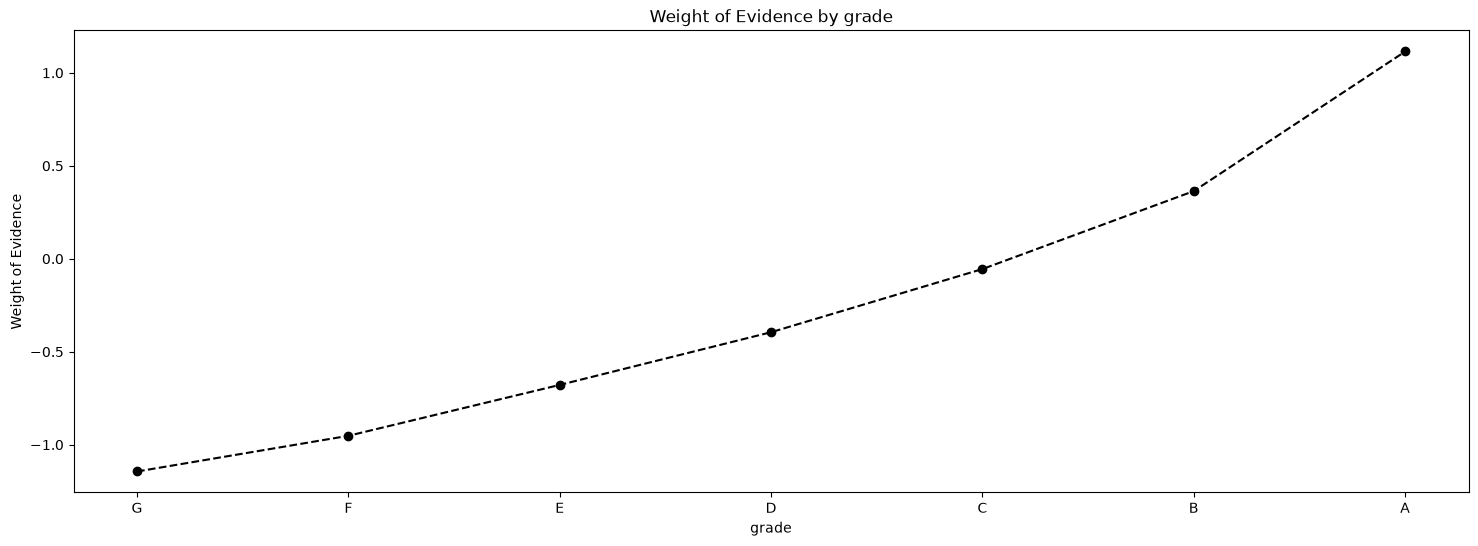

In [28]:
plot_by_woe(df_temp)

## Preprocessing Discrete Variables: Creating Dummpy Variables

#### **home_ownership** column

In [29]:
df_temp = woe_discrete(df_inputs_prepr, 'home_ownership', df_targets_prepr)

df_temp

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,OTHER,182,0.791209,0.000390,144.0,38.0,0.000347,0.000746,-0.765617,NaN,NaN,inf
1,NONE,50,0.840000,0.000107,42.0,8.0,0.000101,0.000157,-0.439616,0.048791,0.326001,inf
2,RENT,188473,0.873897,0.404201,164706.0,23767.0,0.396579,0.466312,-0.161980,0.033897,0.277636,inf
3,OWN,41704,0.891737,0.089439,37189.0,4515.0,0.089544,0.088585,0.010764,0.017840,0.172744,inf
4,MORTGAGE,235875,0.904017,0.505860,213235.0,22640.0,0.513427,0.444200,0.144832,0.012280,0.134069,inf
5,ANY,1,1.000000,0.000002,1.0,0.0,0.000002,0.000000,inf,0.095983,inf,inf


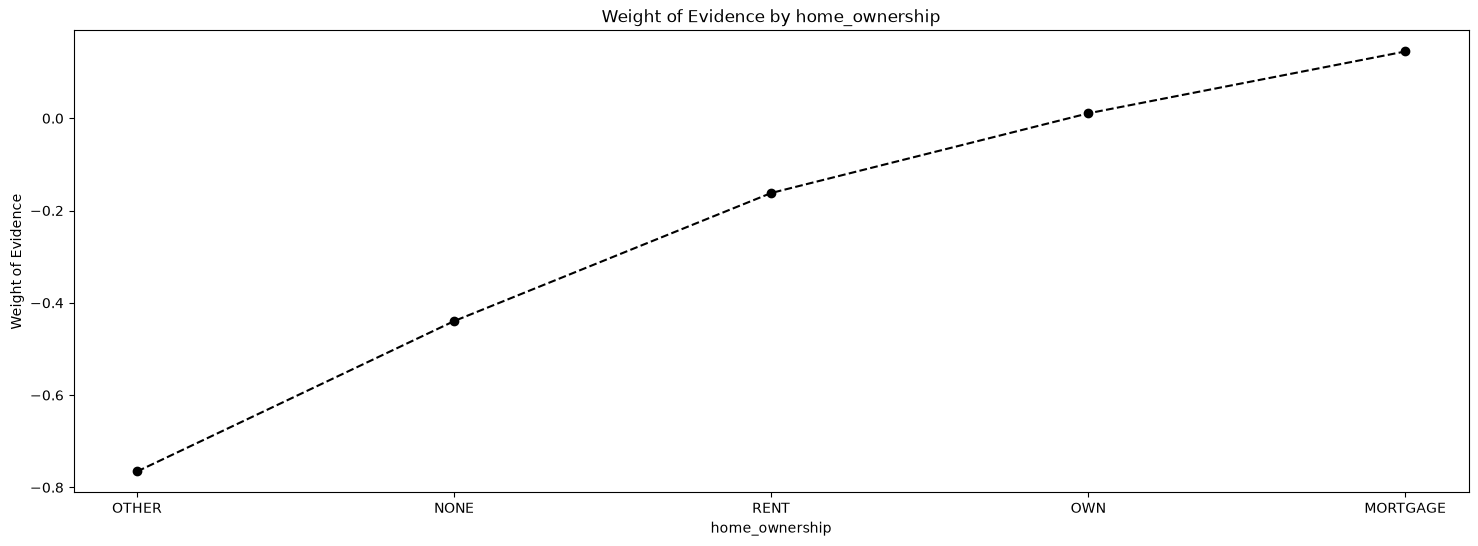

In [30]:
plot_by_woe(df_temp)

After WoE analysis, We decided to combine some categories: RENT + OTHER + NONE + ANY into one new categoriy home_ownership:RENT_OTHER_NONE_ANY

In [31]:
df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'] = sum([
    df_inputs_prepr['home_ownership:RENT'],
    df_inputs_prepr['home_ownership:OTHER'],
    df_inputs_prepr['home_ownership:NONE'],
    df_inputs_prepr['home_ownership:ANY'],
])

C:\Users\k\AppData\Local\Temp\ipykernel_16576\1992964054.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'] = sum([


#### **addr_state** column

In [32]:
df_inputs_prepr['addr_state'].unique()

<StringArray>
['AZ', 'GA', 'IL', 'CA', 'OR', 'NC', 'TX', 'VA', 'MO', 'CT', 'UT', 'FL', 'NY',
 'PA', 'MN', 'NJ', 'KY', 'OH', 'SC', 'RI', 'LA', 'MA', 'WA', 'WI', 'AL', 'CO',
 'KS', 'NV', 'AK', 'MD', 'WV', 'VT', 'MI', 'DC', 'SD', 'NH', 'AR', 'NM', 'MT',
 'HI', 'WY', 'OK', 'DE', 'MS', 'TN', 'IA', 'NE', 'ID', 'IN', 'ME']
Length: 50, dtype: str

In [33]:
df_temp = woe_discrete(df_inputs_prepr, 'addr_state', df_targets_prepr)

df_temp

,addr_state,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,NE,14,0.428571,0.000030,6.0,8.0,0.000014,0.000157,-2.385526,NaN,NaN,inf
1,IA,14,0.785714,0.000030,11.0,3.0,0.000026,0.000059,-0.798561,3.571429e-01,1.586965,inf
2,NV,6519,0.862862,0.013981,5625.0,894.0,0.013544,0.017540,-0.258574,7.714812e-02,0.539987,inf
3,HI,2487,0.873743,0.005334,2173.0,314.0,0.005232,0.006161,-0.163373,1.088106e-02,0.095201,inf
4,FL,31637,0.874640,0.067849,27671.0,3966.0,0.066626,0.077814,-0.155217,8.969866e-04,0.008156,inf
5,AL,5853,0.876474,0.012552,5130.0,723.0,0.012352,0.014185,-0.138392,1.833151e-03,0.016825,inf
6,NY,40242,0.883182,0.086303,35541.0,4701.0,0.085576,0.092234,-0.074932,6.708147e-03,0.063460,inf
7,LA,5489,0.883403,0.011772,4849.0,640.0,0.011675,0.012557,-0.072784,2.214196e-04,0.002148,inf
8,NM,2588,0.884467,0.005550,2289.0,299.0,0.005511,0.005866,-0.062417,1.063600e-03,0.010367,inf
9,OK,4117,0.884625,0.008829,3642.0,475.0,0.008769,0.009320,-0.060871,1.579570e-04,0.001547,inf


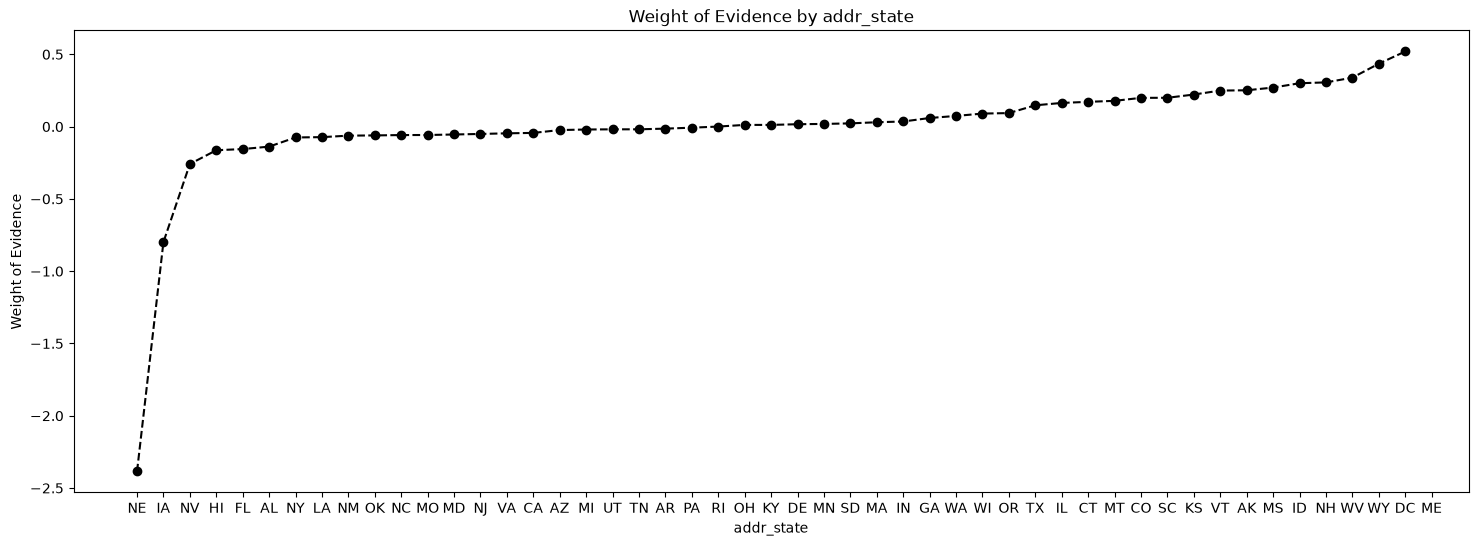

In [34]:
plot_by_woe(df_temp)

In [35]:
if 'addr_state:ND' in df_inputs_prepr.columns.values:
    pass
else:
    df_inputs_prepr['addr_state:ND'] = 0

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3630874620.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['addr_state:ND'] = 0


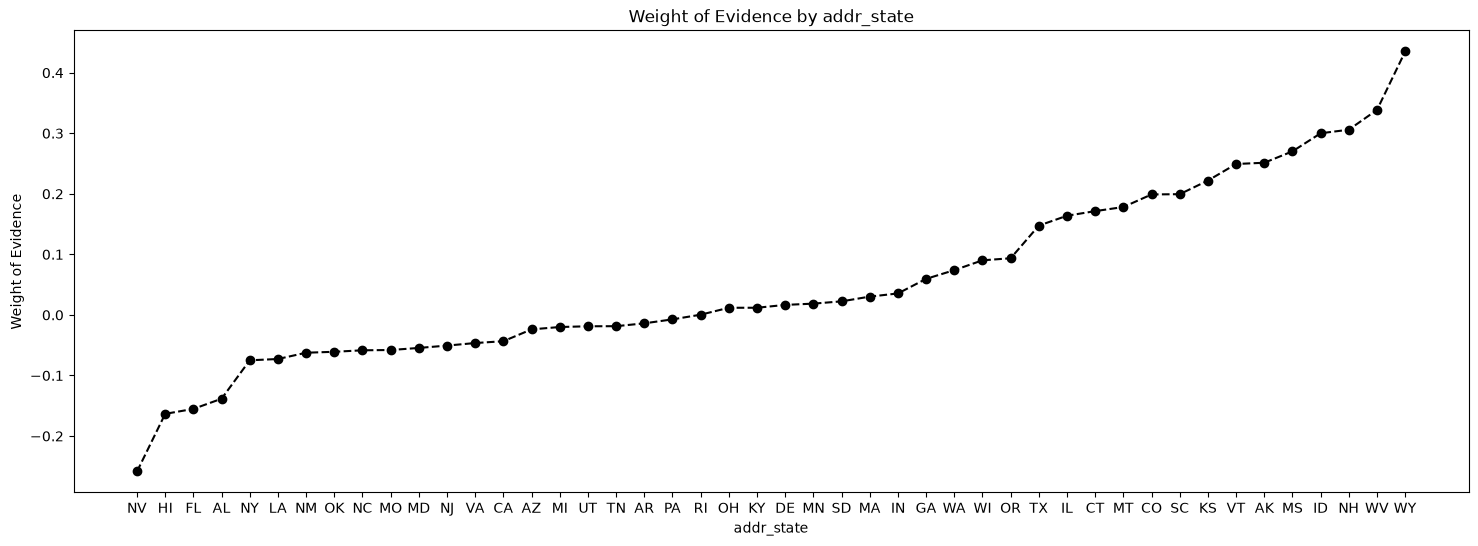

In [36]:
plot_by_woe(df_temp.iloc[2: -2, : ])

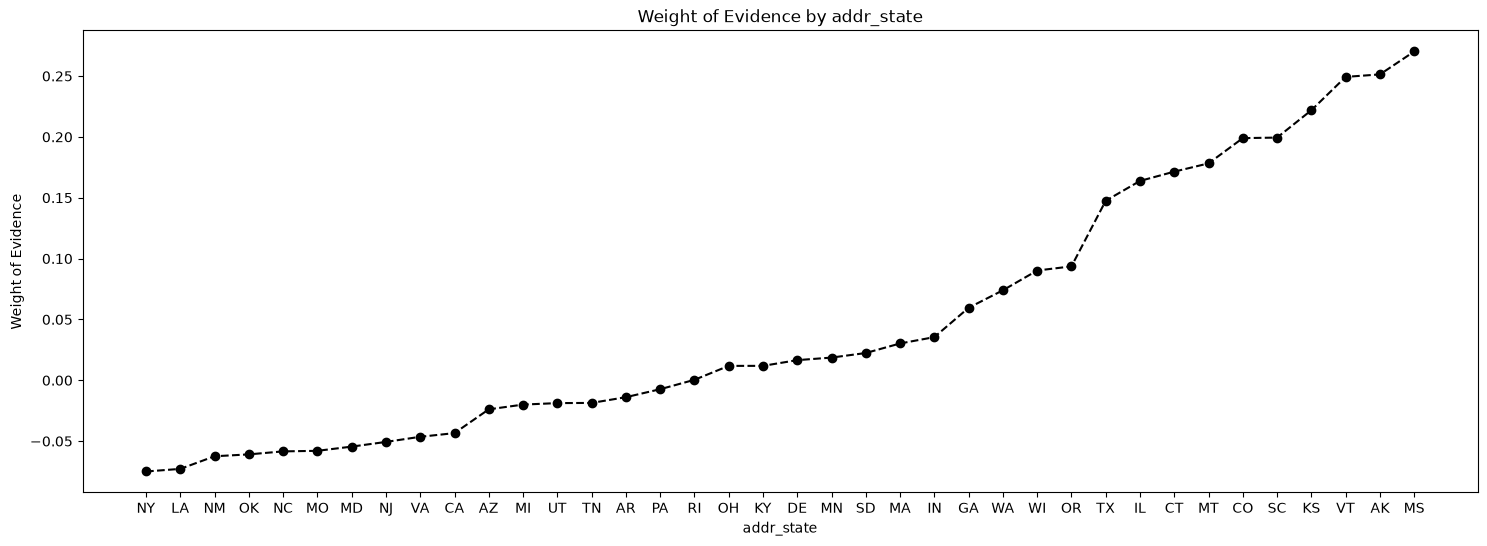

In [37]:
plot_by_woe(df_temp.iloc[6: -6, : ])

In [38]:
# We create the following categories:
# 'ND' 'NE' 'IA' NV' 'FL' 'HI' 'AL'
# 'NM' 'VA'
# 'NY'
# 'OK' 'TN' 'MO' 'LA' 'MD' 'NC'
# 'CA'
# 'UT' 'KY' 'AZ' 'NJ'
# 'AR' 'MI' 'PA' 'OH' 'MN'
# 'RI' 'MA' 'DE' 'SD' 'IN'
# 'GA' 'WA' 'OR'
# 'WI' 'MT'
# 'TX'
# 'IL' 'CT'
# 'KS' 'SC' 'CO' 'VT' 'AK' 'MS'
# 'WV' 'NH' 'WY' 'DC' 'ME' 'ID'

# 'IA_NV_HI_ID_AL_FL' will be the reference category.

df_inputs_prepr['addr_state:ND_NE_IA_NV_FL_HI_AL'] = sum([df_inputs_prepr['addr_state:ND'], df_inputs_prepr['addr_state:NE'],
                                              df_inputs_prepr['addr_state:IA'], df_inputs_prepr['addr_state:NV'],
                                              df_inputs_prepr['addr_state:FL'], df_inputs_prepr['addr_state:HI'],
                                                          df_inputs_prepr['addr_state:AL']])

df_inputs_prepr['addr_state:NM_VA'] = sum([df_inputs_prepr['addr_state:NM'], df_inputs_prepr['addr_state:VA']])

df_inputs_prepr['addr_state:OK_TN_MO_LA_MD_NC'] = sum([df_inputs_prepr['addr_state:OK'], df_inputs_prepr['addr_state:TN'],
                                              df_inputs_prepr['addr_state:MO'], df_inputs_prepr['addr_state:LA'],
                                              df_inputs_prepr['addr_state:MD'], df_inputs_prepr['addr_state:NC']])

df_inputs_prepr['addr_state:UT_KY_AZ_NJ'] = sum([df_inputs_prepr['addr_state:UT'], df_inputs_prepr['addr_state:KY'],
                                              df_inputs_prepr['addr_state:AZ'], df_inputs_prepr['addr_state:NJ']])

df_inputs_prepr['addr_state:AR_MI_PA_OH_MN'] = sum([df_inputs_prepr['addr_state:AR'], df_inputs_prepr['addr_state:MI'],
                                              df_inputs_prepr['addr_state:PA'], df_inputs_prepr['addr_state:OH'],
                                              df_inputs_prepr['addr_state:MN']])

df_inputs_prepr['addr_state:RI_MA_DE_SD_IN'] = sum([df_inputs_prepr['addr_state:RI'], df_inputs_prepr['addr_state:MA'],
                                              df_inputs_prepr['addr_state:DE'], df_inputs_prepr['addr_state:SD'],
                                              df_inputs_prepr['addr_state:IN']])

df_inputs_prepr['addr_state:GA_WA_OR'] = sum([df_inputs_prepr['addr_state:GA'], df_inputs_prepr['addr_state:WA'],
                                              df_inputs_prepr['addr_state:OR']])

df_inputs_prepr['addr_state:WI_MT'] = sum([df_inputs_prepr['addr_state:WI'], df_inputs_prepr['addr_state:MT']])

df_inputs_prepr['addr_state:IL_CT'] = sum([df_inputs_prepr['addr_state:IL'], df_inputs_prepr['addr_state:CT']])

df_inputs_prepr['addr_state:KS_SC_CO_VT_AK_MS'] = sum([df_inputs_prepr['addr_state:KS'], df_inputs_prepr['addr_state:SC'],
                                              df_inputs_prepr['addr_state:CO'], df_inputs_prepr['addr_state:VT'],
                                              df_inputs_prepr['addr_state:AK'], df_inputs_prepr['addr_state:MS']])

df_inputs_prepr['addr_state:WV_NH_WY_DC_ME_ID'] = sum([df_inputs_prepr['addr_state:WV'], df_inputs_prepr['addr_state:NH'],
                                              df_inputs_prepr['addr_state:WY'], df_inputs_prepr['addr_state:DC'],
                                              df_inputs_prepr['addr_state:ME'], df_inputs_prepr['addr_state:ID']])

C:\Users\k\AppData\Local\Temp\ipykernel_16576\2841497047.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['addr_state:ND_NE_IA_NV_FL_HI_AL'] = sum([df_inputs_prepr['addr_state:ND'], df_inputs_prepr['addr_state:NE'],
C:\Users\k\AppData\Local\Temp\ipykernel_16576\2841497047.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['addr_state:NM_VA'] = sum([df_inputs_prepr['addr_state:NM'], df_inputs_prepr['addr_state:VA']])
C:\Users\k\AppData\Local\Temp\ipykernel_16576\2841497047.py:26: PerformanceW

#### **verification_status** column 

In [39]:
df_temp = woe_discrete(df_inputs_prepr, 'verification_status', df_targets_prepr)
df_temp

,verification_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,Verified,168055,0.872631,0.360413,146650.0,21405.0,0.353104,0.419969,-0.173420,NaN,NaN,0.020831
1,Source Verified,149993,0.895882,0.321677,134376.0,15617.0,0.323550,0.306408,0.054438,0.023251,0.227858,0.020831
2,Not Verified,148237,0.905921,0.317911,134291.0,13946.0,0.323346,0.273623,0.166972,0.010039,0.112535,0.020831


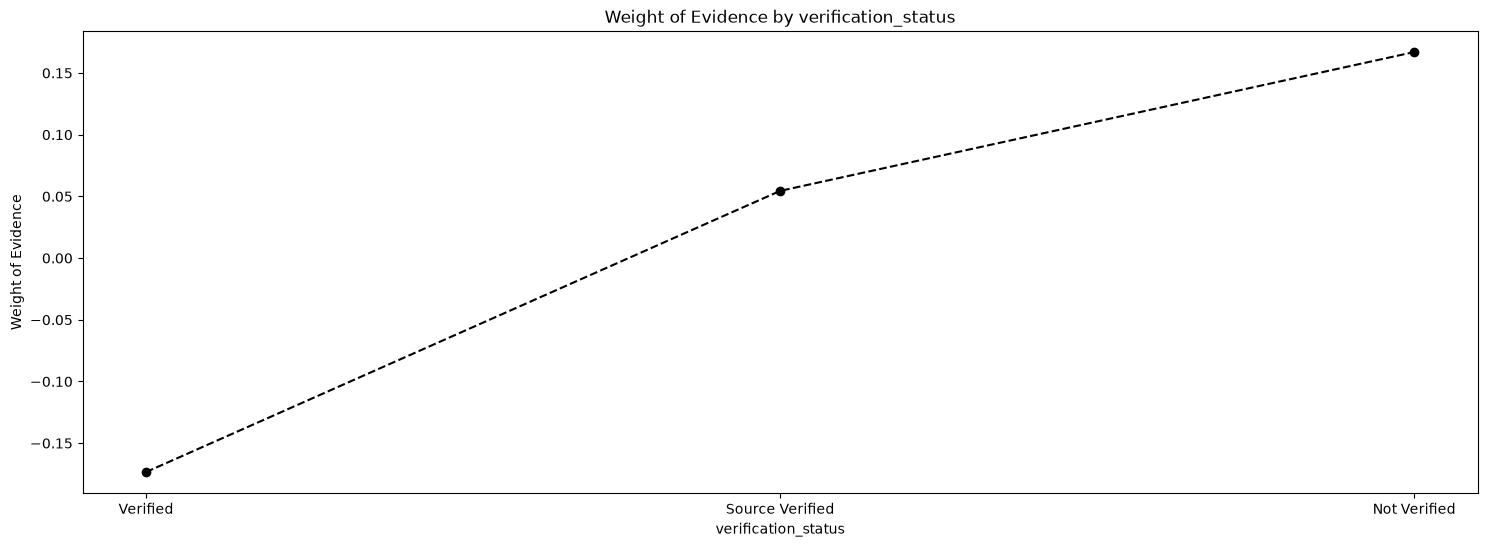

In [40]:
plot_by_woe(df_temp)

#### **purpose** column

In [41]:
df_temp = woe_discrete(df_inputs_prepr, 'purpose', df_targets_prepr)
df_temp

,purpose,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,small_business,7013,0.784258,0.015040,5500.0,1513.0,0.013243,0.029685,-0.807190,NaN,NaN,0.03698
1,educational,422,0.791469,0.000905,334.0,88.0,0.000804,0.001727,-0.764040,0.007211,0.043151,0.03698
2,renewable_energy,351,0.846154,0.000753,297.0,54.0,0.000715,0.001059,-0.393096,0.054685,0.370944,0.03698
3,moving,2994,0.847361,0.006421,2537.0,457.0,0.006109,0.008966,-0.383790,0.001208,0.009306,0.03698
4,house,2269,0.859850,0.004866,1951.0,318.0,0.004698,0.006239,-0.283798,0.012489,0.099992,0.03698
5,other,23690,0.862009,0.050806,20421.0,3269.0,0.049170,0.064138,-0.265764,0.002159,0.018034,0.03698
6,medical,4602,0.866145,0.009870,3986.0,616.0,0.009597,0.012086,-0.230548,0.004136,0.035217,0.03698
7,wedding,2343,0.878361,0.005025,2058.0,285.0,0.004955,0.005592,-0.120843,0.012216,0.109704,0.03698
8,vacation,2487,0.882187,0.005334,2194.0,293.0,0.005283,0.005749,-0.084535,0.003826,0.036308,0.03698
9,debt_consolidation,274195,0.886690,0.588042,243126.0,31069.0,0.585399,0.609579,-0.040475,0.004503,0.044060,0.03698


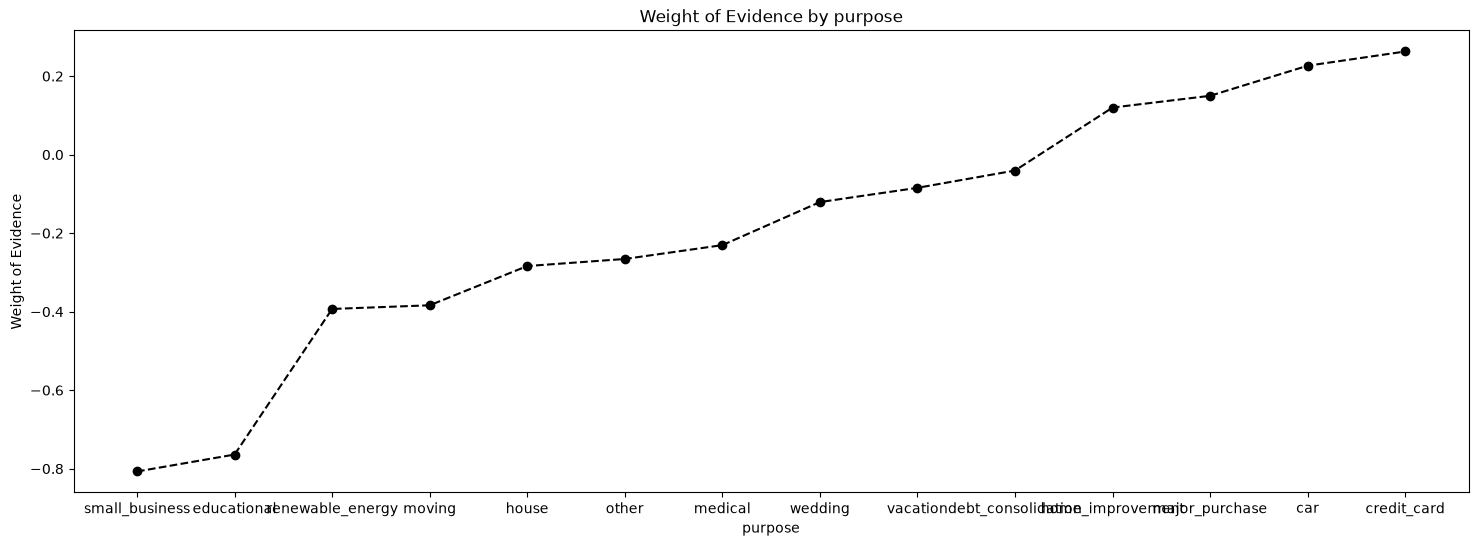

In [42]:
plot_by_woe(df_temp)

In [43]:
# We combine 'educational', 'small_business', 'wedding', 'renewable_energy', 'moving', 'house' in one category: 'educ__sm_b__wedd__ren_en__mov__house'.
# We combine 'other', 'medical', 'vacation' in one category: 'oth__med__vacation'.
# We combine 'major_purchase', 'car', 'home_improvement' in one category: 'major_purch__car__home_impr'.
# We leave 'debt_consolidtion' in a separate category.
# We leave 'credit_card' in a separate category.
# 'educ__sm_b__wedd__ren_en__mov__house' will be the reference category.

df_inputs_prepr['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([
    df_inputs_prepr['purpose:educational'], 
    df_inputs_prepr['purpose:small_business'],
    df_inputs_prepr['purpose:wedding'], 
    df_inputs_prepr['purpose:renewable_energy'],
    df_inputs_prepr['purpose:moving'], 
    df_inputs_prepr['purpose:house']
])

df_inputs_prepr['purpose:oth__med__vacation'] = sum([
    df_inputs_prepr['purpose:other'], 
    df_inputs_prepr['purpose:medical'],
    df_inputs_prepr['purpose:vacation']
])

df_inputs_prepr['purpose:major_purch__car__home_impr'] = sum([
    df_inputs_prepr['purpose:major_purchase'], 
    df_inputs_prepr['purpose:car'],
    df_inputs_prepr['purpose:home_improvement']
])

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3911802371.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3911802371.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['purpose:oth__med__vacation'] = sum([
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3911802371.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

#### **initial_list_status** column 

In [44]:
df_temp = woe_discrete(df_inputs_prepr, 'initial_list_status', df_targets_prepr)
df_temp

,initial_list_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,f,303005,0.879692,0.649828,266551.0,36454.0,0.641801,0.715233,-0.108330,NaN,NaN,0.024801
1,w,163280,0.911110,0.350172,148766.0,14514.0,0.358199,0.284767,0.229417,0.031418,0.337746,0.024801


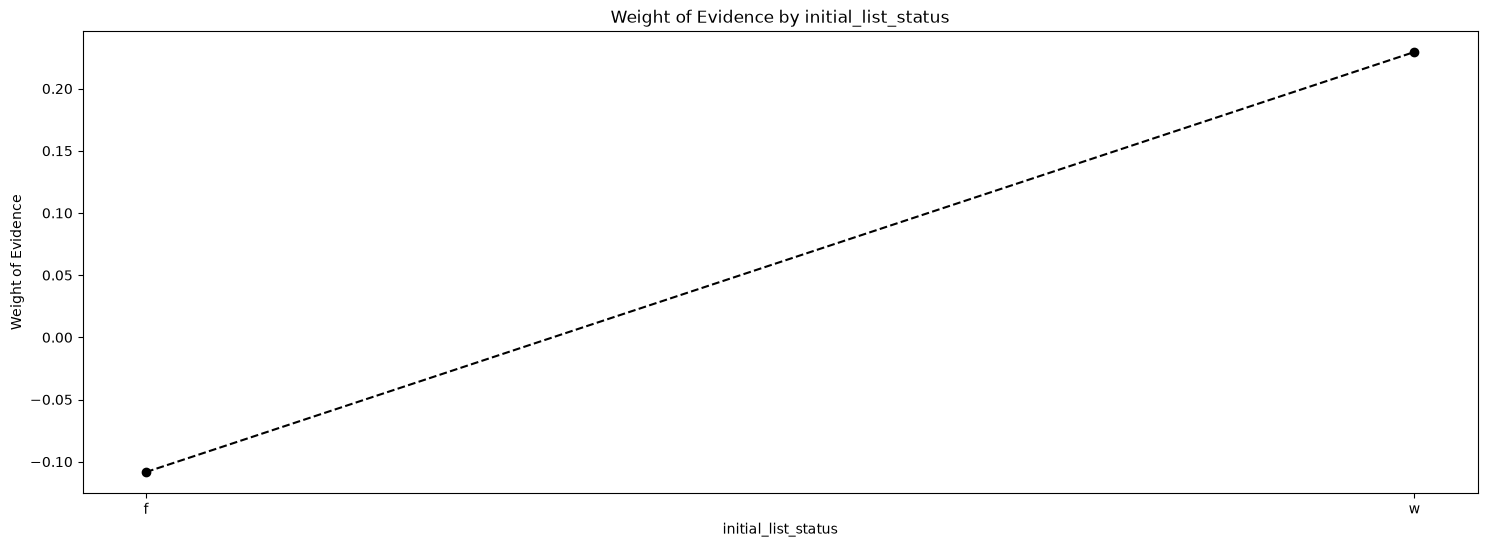

In [45]:
plot_by_woe(df_temp)

## Preprocessing Continuous Variables: Automating Calculations and Visualizing Results

In [46]:
def woe_ordered_continuous(df, variable_name, good_bad_variable_df):
    df = pd.concat([
        df[variable_name], good_bad_variable_df
    ], axis=1)

    df = pd.concat([
        df.groupby(df.columns.values[0], as_index=False)[df.columns.values[1]].count(),
        df.groupby(df.columns.values[0], as_index=False)[df.columns.values[1]].mean(),
    ], axis=1)

    df = df.iloc[:, [0, 1, 3]]

    df.columns = [df.columns[0], 'n_obs', 'prop_good']

    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()

    df['n_good'] = df['prop_good'] * df['n_obs']

    df['n_bad'] = (1- df['prop_good'] * df['n_obs'])

    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()

    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()

    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])

    df['diff_prop_good'] = df['prop_good'].diff().abs()

    df['diff_WoE'] = df['WoE'].diff().abs()

    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    
    df['IV'] = df['IV'].sum()
    return df


## Preprocessing Continuous Variables

#### **term** column 

In [47]:
df_inputs_prepr['term_int'].unique()

array([36, 60])

In [48]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'term_int', df_targets_prepr)
df_temp

,term_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,36,337953,0.902915,0.724778,305143.0,-305142.0,0.734723,0.734724,-0.000002,NaN,NaN,6.555321e-12
1,60,128332,0.858508,0.275222,110174.0,-110173.0,0.265277,0.265276,0.000004,0.044408,0.000006,6.555321e-12


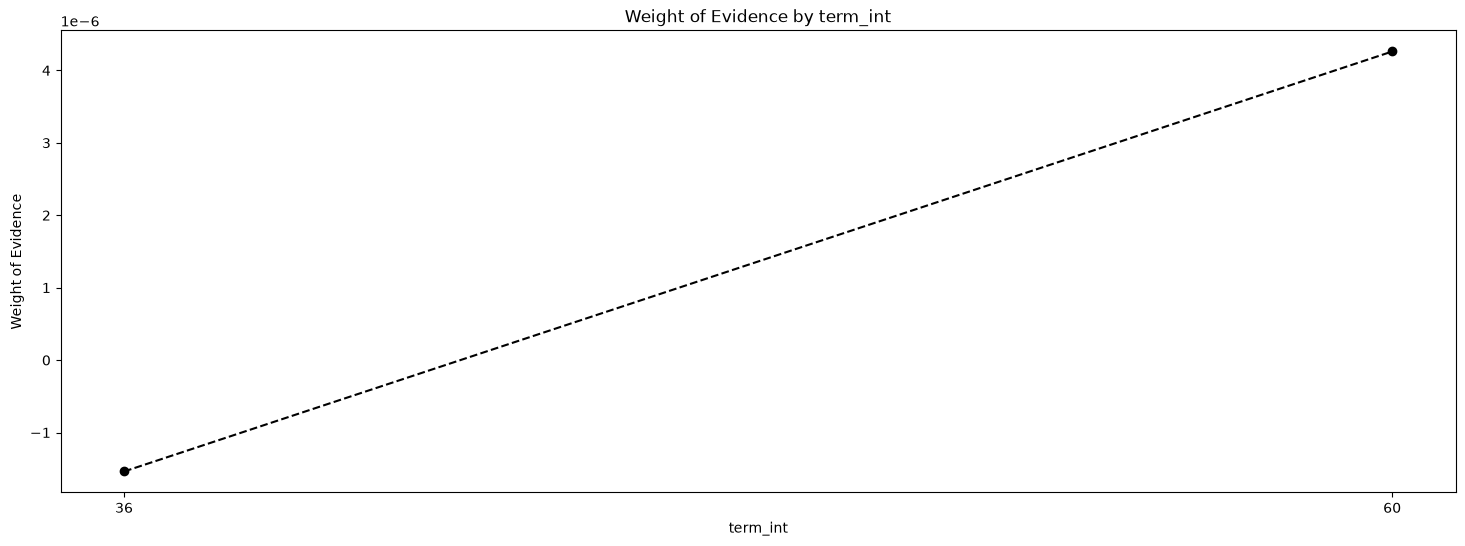

In [49]:
plot_by_woe(df_temp)

In [50]:
df_inputs_prepr['term:36'] = np.where(
    (df_inputs_prepr['term_int'] == 36),
    1,
    0
)

df_inputs_prepr['term:60'] = np.where(
    (df_inputs_prepr['term_int'] == 60),
    1,
    0
)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3937287929.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['term:36'] = np.where(
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3937287929.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['term:60'] = np.where(


#### **emp_length_int** column 

In [51]:
df_inputs_prepr['emp_length_int'].unique()

array([10.,  0.,  1.,  3.,  8.,  9.,  4.,  5.,  6.,  2.,  7.])

In [52]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'emp_length_int', df_targets_prepr)
df_temp

,emp_length_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,57273,0.876015,0.122828,50172.0,-50171.0,0.120804,0.120805,-6.554509e-06,NaN,NaN,2.603601e-10
1,1.0,29622,0.888124,0.063528,26308.0,-26307.0,0.063344,0.063344,1.152583e-05,0.012109,1.808034e-05,2.603601e-10
2,2.0,41373,0.890242,0.088729,36832.0,-36831.0,0.088684,0.088684,6.645291e-07,0.002119,1.086130e-05,2.603601e-10
3,3.0,36596,0.890480,0.078484,32588.0,-32587.0,0.078465,0.078465,4.200469e-06,0.000237,3.535940e-06,2.603601e-10
4,4.0,28023,0.890411,0.060098,24952.0,-24951.0,0.060079,0.060079,1.359161e-05,0.000068,9.391138e-06,2.603601e-10
5,5.0,30774,0.885033,0.065998,27236.0,-27235.0,0.065579,0.065578,1.023064e-05,0.005379,3.360966e-06,2.603601e-10
6,6.0,26112,0.882889,0.056000,23054.0,-23053.0,0.055509,0.055508,1.689122e-05,0.002144,6.660576e-06,2.603601e-10
7,7.0,26180,0.888655,0.056146,23265.0,-23264.0,0.056017,0.056017,1.649780e-05,0.005766,3.934159e-07,2.603601e-10
8,8.0,22395,0.889931,0.048029,19930.0,-19929.0,0.047987,0.047986,2.369073e-05,0.001275,7.192928e-06,2.603601e-10
9,9.0,17888,0.887914,0.038363,15883.0,-15882.0,0.038243,0.038242,3.647624e-05,0.002017,1.278551e-05,2.603601e-10


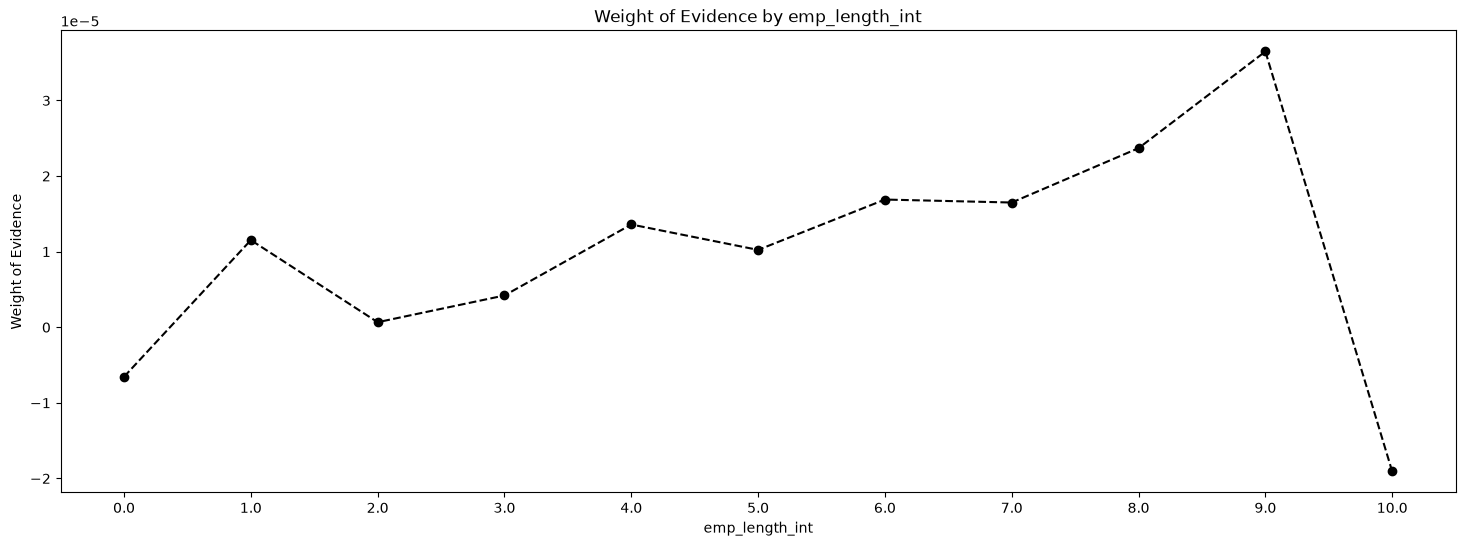

In [53]:
plot_by_woe(df_temp)

In [54]:
# We create the following categories: '0', '1', '2 - 4', '5 - 6', '7 - 9', '10'
# '0' will be the reference category
df_inputs_prepr['emp_length:0'] = np.where(df_inputs_prepr['emp_length_int'].isin([0]), 1, 0)
df_inputs_prepr['emp_length:1'] = np.where(df_inputs_prepr['emp_length_int'].isin([1]), 1, 0)
df_inputs_prepr['emp_length:2-4'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(2, 5)), 1, 0)
df_inputs_prepr['emp_length:5-6'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(5, 7)), 1, 0)
df_inputs_prepr['emp_length:7-9'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(7, 10)), 1, 0)
df_inputs_prepr['emp_length:10'] = np.where(df_inputs_prepr['emp_length_int'].isin([10]), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\1956586947.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['emp_length:0'] = np.where(df_inputs_prepr['emp_length_int'].isin([0]), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\1956586947.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['emp_length:1'] = np.where(df_inputs_prepr['emp_length_int'].isin([1]), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\1956586947.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usua

#### **mths_since_issue_d** column

In [55]:
df_inputs_prepr['mths_since_issue_d'].unique()

array([ 72.,  73.,  74.,  75.,  76.,  77.,  78.,  79.,  80.,  81.,  82.,
        83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,  91.,  92.,  93.,
        94.,  95.,  96.,  97.,  98.,  99., 100., 101., 102., 103., 104.,
       105., 106., 107., 108., 109., 110., 111., 112., 113., 114., 115.,
       116., 117., 118., 119., 120., 121., 122., 123., 124., 125., 126.,
        48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.,
        59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,  68.,  69.,
        70.,  71.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.])

In [56]:
df_inputs_prepr['mths_since_issue_d_factor'] = pd.cut(df_inputs_prepr['mths_since_issue_d'], 50)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\1781457706.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_issue_d_factor'] = pd.cut(df_inputs_prepr['mths_since_issue_d'], 50)


In [57]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_issue_d_factor', df_targets_prepr)
df_temp

,mths_since_issue_d_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(35.91, 37.8]",35361,0.942960,0.075836,33344.0,-33343.0,0.080286,0.080293,-0.000090,NaN,NaN,1.859117e-07
1,"(37.8, 39.6]",49388,0.928809,0.105918,45872.0,-45871.0,0.110451,0.110461,-0.000099,0.014151,8.190824e-06,1.859117e-07
2,"(39.6, 41.4]",48120,0.917810,0.103199,44165.0,-44164.0,0.106340,0.106351,-0.000098,0.010999,8.425919e-07,1.859117e-07
3,"(41.4, 43.2]",36278,0.908705,0.077802,32966.0,-32965.0,0.079376,0.079383,-0.000090,0.009105,7.692124e-06,1.859117e-07
4,"(43.2, 45.0]",35584,0.902007,0.076314,32097.0,-32096.0,0.077283,0.077290,-0.000089,0.006698,8.213012e-07,1.859117e-07
5,"(45.0, 46.8]",15269,0.898487,0.032746,13719.0,-13718.0,0.033033,0.033034,-0.000048,0.003519,4.173822e-05,1.859117e-07
6,"(46.8, 48.6]",30648,0.897155,0.065728,27496.0,-27495.0,0.066205,0.066210,-0.000084,0.001332,3.652468e-05,1.859117e-07
7,"(48.6, 50.4]",28790,0.887843,0.061743,25561.0,-25560.0,0.061546,0.061551,-0.000081,0.009312,2.753278e-06,1.859117e-07
8,"(50.4, 52.2]",25661,0.880207,0.055033,22587.0,-22586.0,0.054385,0.054389,-0.000076,0.007636,5.151369e-06,1.859117e-07
9,"(52.2, 54.0]",22809,0.868298,0.048916,19805.0,-19804.0,0.047686,0.047690,-0.000070,0.011910,6.219340e-06,1.859117e-07


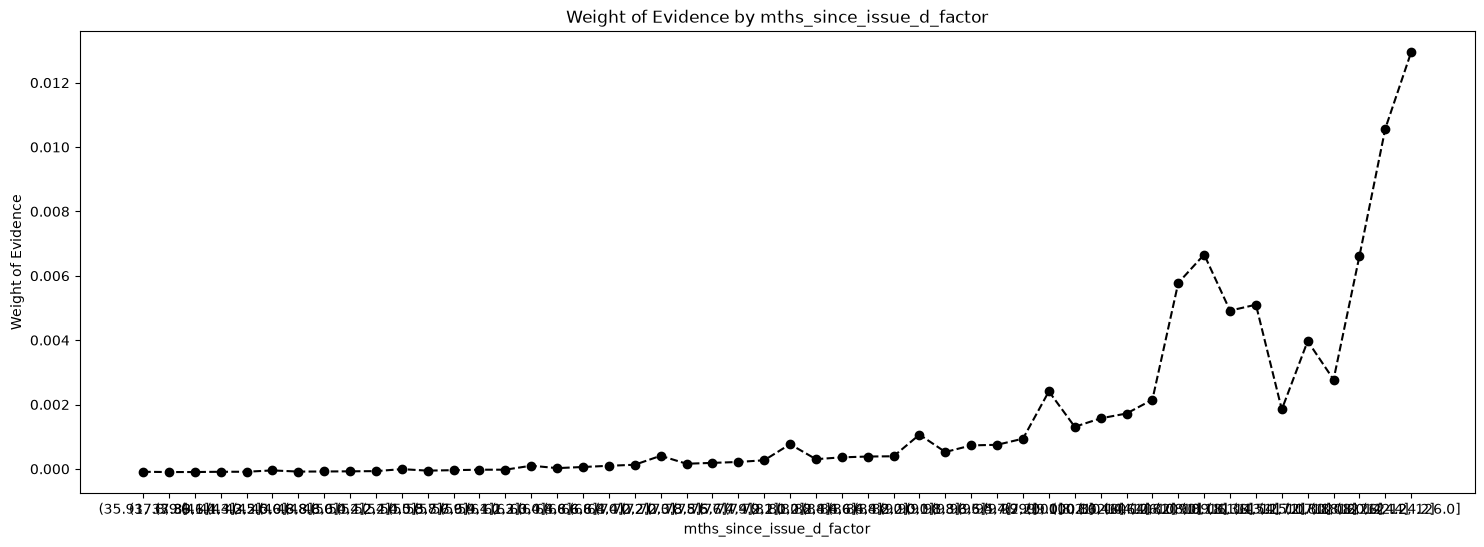

In [58]:
plot_by_woe(df_temp)

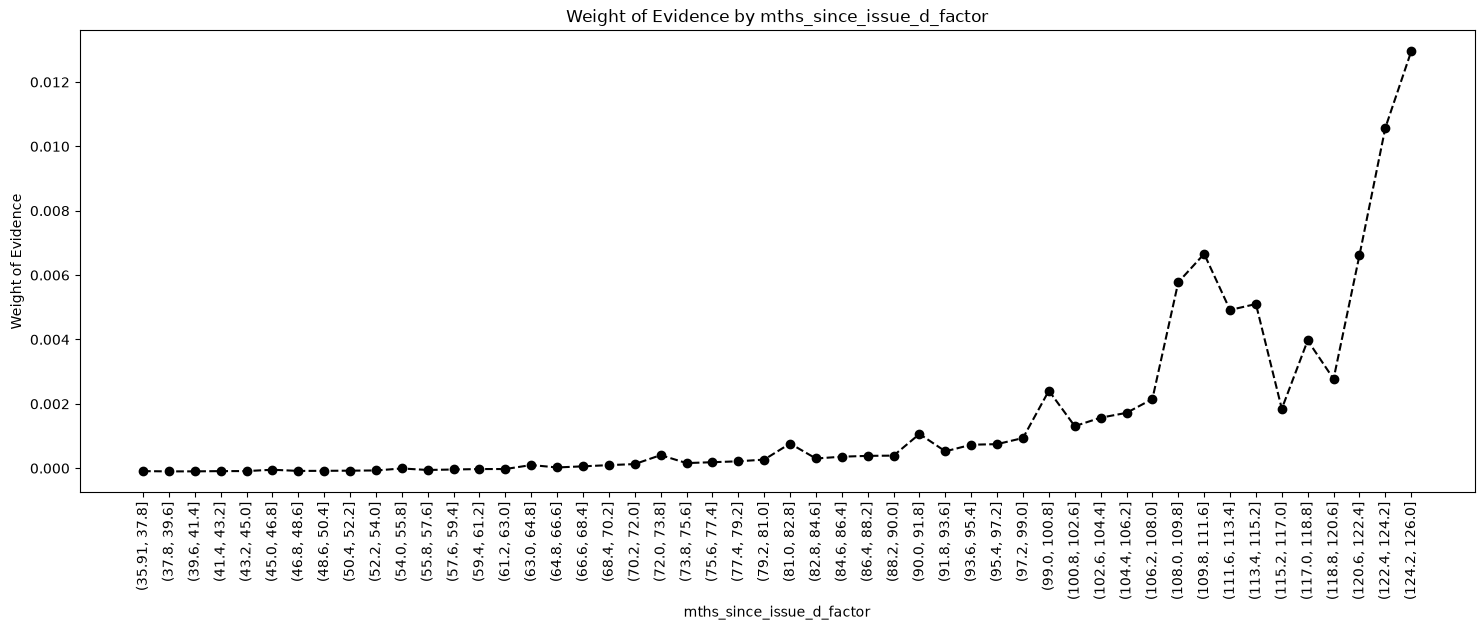

In [59]:
plot_by_woe(df_temp, 90)

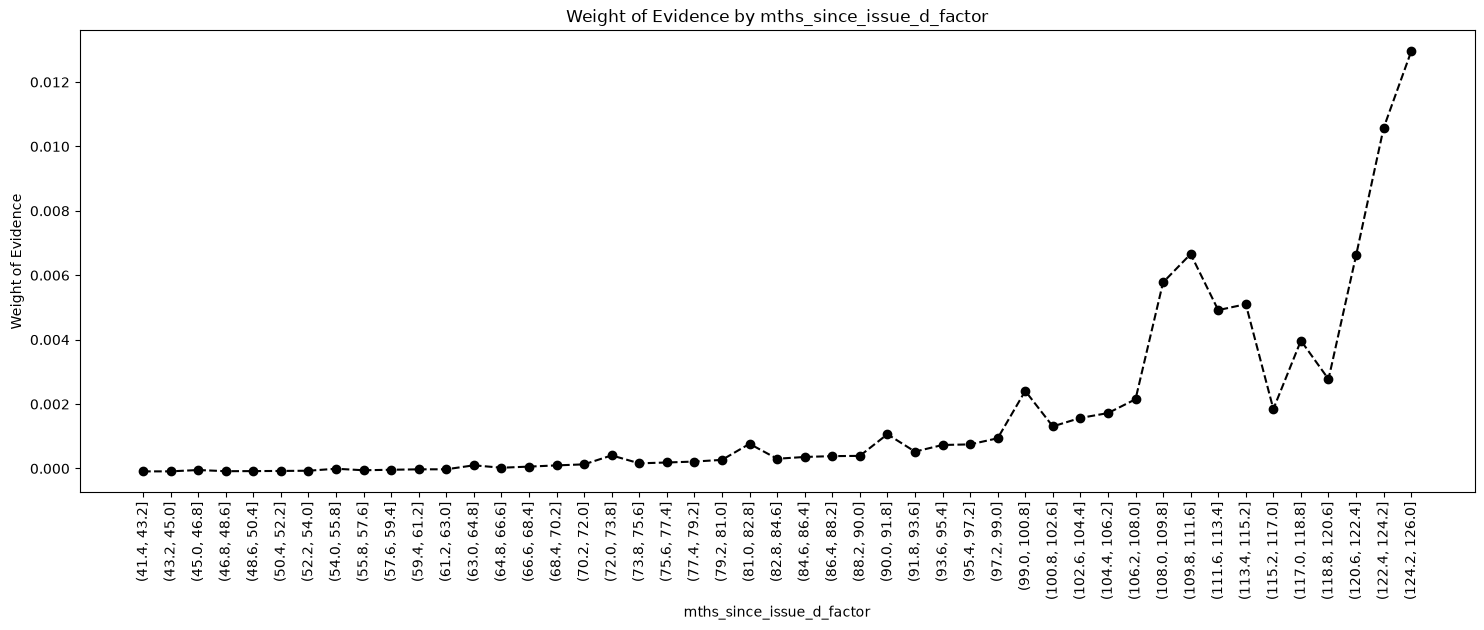

In [60]:
plot_by_woe(df_temp.iloc[3:, :], 90)

In [61]:
# We create the following categories:
"""
< 38, 
38 - 39, 
40 - 41, 
42 - 48, 
49 - 52, 
53 - 64, 
65 - 84, 
> 84
"""
df_inputs_prepr['mths_since_issue_d:<38'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(38)), 1, 0)
df_inputs_prepr['mths_since_issue_d:38-39'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(38, 40)), 1, 0)
df_inputs_prepr['mths_since_issue_d:40-41'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(40, 42)), 1, 0)
df_inputs_prepr['mths_since_issue_d:42-48'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(42, 49)), 1, 0)
df_inputs_prepr['mths_since_issue_d:49-52'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(49, 53)), 1, 0)
df_inputs_prepr['mths_since_issue_d:53-64'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(53, 65)), 1, 0)
df_inputs_prepr['mths_since_issue_d:65-84'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(65, 85)), 1, 0)
df_inputs_prepr['mths_since_issue_d:>84'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(85, int(df_inputs_prepr['mths_since_issue_d'].max()))), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\1880153647.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_issue_d:<38'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(38)), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\1880153647.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_issue_d:38-39'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(38, 40)), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\1880153647.py:14: PerformanceWarni

#### **int_rate** column 

In [62]:
df_inputs_prepr['int_rate']

0         10.65
1         15.27
2         15.96
3         13.49
4         12.69
          ...  
466280    14.47
466281    19.97
466282    16.99
466283     7.90
466284    19.20
Name: int_rate, Length: 466285, dtype: float64

In [63]:
df_inputs_prepr['int_rate_factor'] = pd.cut(df_inputs_prepr['int_rate'], 50)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\488403726.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['int_rate_factor'] = pd.cut(df_inputs_prepr['int_rate'], 50)


In [64]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'int_rate_factor', df_targets_prepr)
df_temp

,int_rate_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(5.399, 5.833]",983,0.963377,0.002108,947.0,-946.0,0.002280,0.002278,0.000936,NaN,NaN,2.050234e-08
1,"(5.833, 6.246]",10545,0.980275,0.022615,10337.0,-10336.0,0.024889,0.024890,-0.000024,0.016898,0.000960,2.050234e-08
2,"(6.246, 6.658]",9800,0.971633,0.021017,9522.0,-9521.0,0.022927,0.022927,-0.000015,0.008642,0.000008,2.050234e-08
3,"(6.658, 7.071]",2293,0.968600,0.004918,2221.0,-2220.0,0.005348,0.005346,0.000330,0.003033,0.000345,2.050234e-08
4,"(7.071, 7.484]",3947,0.977451,0.008465,3858.0,-3857.0,0.009289,0.009288,0.000139,0.008851,0.000191,2.050234e-08
5,"(7.484, 7.897]",15826,0.962972,0.033941,15240.0,-15239.0,0.036695,0.036697,-0.000055,0.014479,0.000194,2.050234e-08
6,"(7.897, 8.31]",12116,0.949653,0.025984,11506.0,-11505.0,0.027704,0.027705,-0.000033,0.013319,0.000021,2.050234e-08
7,"(8.31, 8.722]",8274,0.965313,0.017745,7987.0,-7986.0,0.019231,0.019231,0.000005,0.015660,0.000038,2.050234e-08
8,"(8.722, 9.135]",11923,0.938354,0.025570,11188.0,-11187.0,0.026938,0.026939,-0.000031,0.026959,0.000036,2.050234e-08
9,"(9.135, 9.548]",8271,0.966389,0.017738,7993.0,-7992.0,0.019246,0.019245,0.000005,0.028034,0.000036,2.050234e-08


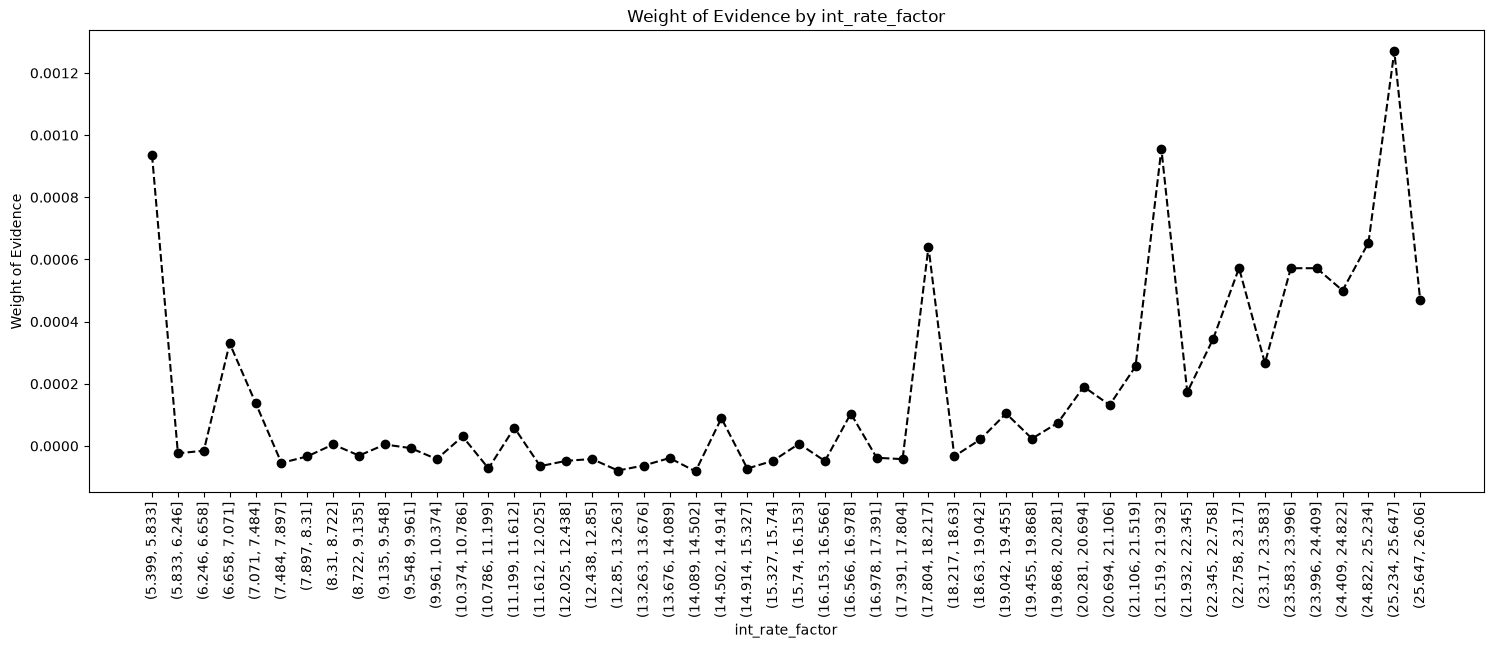

In [65]:
plot_by_woe(df_temp, 90)

In [66]:
""" 
We create the following categories:
    '< 9.548', 
    '9.548 - 12.025', 
    '12.025 - 15.74', 
    '15.74 - 20.281', 
    '> 20.281'
"""

df_inputs_prepr['int_rate:<9.548'] = np.where((df_inputs_prepr['int_rate'] <= 9.548), 1, 0)
df_inputs_prepr['int_rate:9.548-12.025'] = np.where((df_inputs_prepr['int_rate'] > 9.548) & (df_inputs_prepr['int_rate'] <= 12.025), 1, 0)
df_inputs_prepr['int_rate:12.025-15.74'] = np.where((df_inputs_prepr['int_rate'] > 12.025) & (df_inputs_prepr['int_rate'] <= 15.74), 1, 0)
df_inputs_prepr['int_rate:15.74-20.281'] = np.where((df_inputs_prepr['int_rate'] > 15.74) & (df_inputs_prepr['int_rate'] <= 20.281), 1, 0)
df_inputs_prepr['int_rate:>20.281'] = np.where((df_inputs_prepr['int_rate'] > 20.281), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\829278795.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['int_rate:<9.548'] = np.where((df_inputs_prepr['int_rate'] <= 9.548), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\829278795.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['int_rate:9.548-12.025'] = np.where((df_inputs_prepr['int_rate'] > 9.548) & (df_inputs_prepr['int_rate'] <= 12.025), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\829278795.py:12: PerformanceWarning: Da

#### **funded_amnt** column 

In [67]:
df_inputs_prepr['funded_amnt']

0          5000
1          2500
2          2400
3         10000
4          3000
          ...  
466280    18400
466281    22000
466282    20700
466283     2000
466284    10000
Name: funded_amnt, Length: 466285, dtype: int64

In [68]:
df_inputs_prepr['funded_amnt_factor'] = pd.cut(df_inputs_prepr['funded_amnt'], 50)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\2521495186.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['funded_amnt_factor'] = pd.cut(df_inputs_prepr['funded_amnt'], 50)


In [69]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'funded_amnt_factor', df_targets_prepr)
df_temp

,funded_amnt_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(465.5, 1190.0]",1543,0.900194,0.003309,1389.0,-1388.0,0.003344,0.003342,0.000600,NaN,NaN,2.821857e-08
1,"(1190.0, 1880.0]",3828,0.902299,0.008210,3454.0,-3453.0,0.008317,0.008315,0.000169,0.002104,4.306404e-04,2.821857e-08
2,"(1880.0, 2570.0]",7531,0.895100,0.016151,6741.0,-6740.0,0.016231,0.016231,0.000028,0.007199,1.412044e-04,2.821857e-08
3,"(2570.0, 3260.0]",9065,0.890017,0.019441,8068.0,-8067.0,0.019426,0.019426,0.000004,0.005084,2.440281e-05,2.821857e-08
4,"(3260.0, 3950.0]",5996,0.891594,0.012859,5346.0,-5345.0,0.012872,0.012871,0.000067,0.001578,6.311910e-05,2.821857e-08
5,"(3950.0, 4640.0]",11321,0.889321,0.024279,10068.0,-10067.0,0.024242,0.024242,-0.000021,0.002274,8.774371e-05,2.821857e-08
6,"(4640.0, 5330.0]",19860,0.893353,0.042592,17742.0,-17741.0,0.042719,0.042722,-0.000064,0.004033,4.296451e-05,2.821857e-08
7,"(5330.0, 6020.0]",21422,0.906171,0.045942,19412.0,-19411.0,0.046740,0.046743,-0.000069,0.012818,4.849166e-06,2.821857e-08
8,"(6020.0, 6710.0]",8632,0.886469,0.018512,7652.0,-7651.0,0.018424,0.018424,0.000010,0.019702,7.917747e-05,2.821857e-08
9,"(6710.0, 7400.0]",14686,0.897113,0.031496,13175.0,-13174.0,0.031723,0.031724,-0.000044,0.010644,5.478912e-05,2.821857e-08


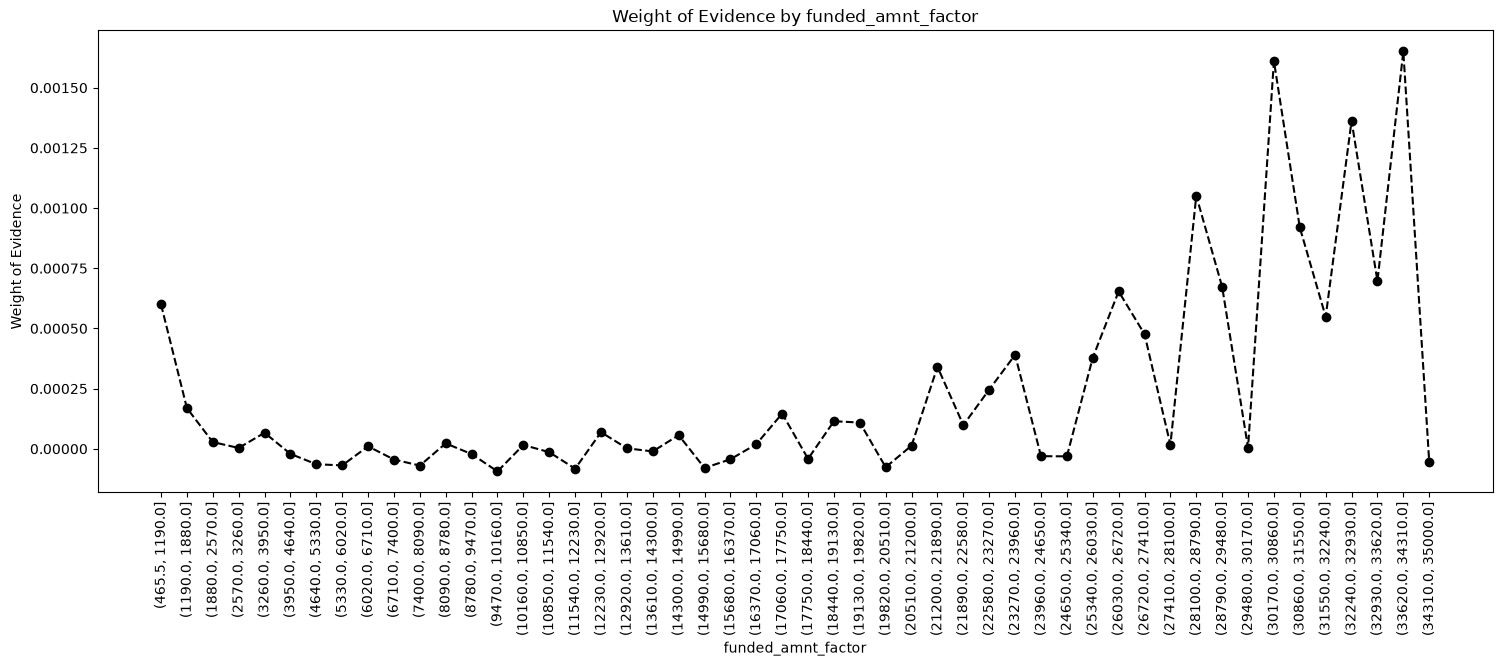

In [70]:
plot_by_woe(df_temp, 90)

#### **mths_since_earliest_cr_line** column

In [71]:
df_inputs_prepr['mths_since_earliest_cr_line'] 

0         395.0
1         224.0
2         193.0
3         262.0
4         263.0
          ...  
466280    176.0
466281    246.0
466282    192.0
466283    178.0
466284    214.0
Name: mths_since_earliest_cr_line, Length: 466285, dtype: float64

In [72]:
df_inputs_prepr['mths_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr['mths_since_earliest_cr_line'], 50)


C:\Users\k\AppData\Local\Temp\ipykernel_16576\2877945852.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr['mths_since_earliest_cr_line'], 50)


In [73]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_earliest_cr_line_factor', df_targets_prepr)
df_temp

,mths_since_earliest_cr_line_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.587, 11.74]",29,0.896552,0.000062,26.0,-25.0,0.000063,0.000060,0.039112,NaN,NaN,1.331038e-07
1,"(70.44, 82.18]",904,0.903761,0.001939,817.0,-816.0,0.001967,0.001965,0.001116,0.007209,3.799597e-02,1.331038e-07
2,"(82.18, 93.92]",2437,0.890849,0.005226,2171.0,-2170.0,0.005227,0.005225,0.000352,0.012912,7.640166e-04,1.331038e-07
3,"(93.92, 105.66]",3532,0.856172,0.007575,3024.0,-3023.0,0.007281,0.007280,0.000222,0.034677,1.299808e-04,1.331038e-07
4,"(105.66, 117.4]",6360,0.867925,0.013640,5520.0,-5519.0,0.013291,0.013290,0.000073,0.011752,1.495667e-04,1.331038e-07
5,"(117.4, 129.14]",11531,0.866534,0.024730,9992.0,-9991.0,0.024059,0.024059,-0.000008,0.001391,8.109076e-05,1.331038e-07
6,"(129.14, 140.88]",14517,0.864573,0.031133,12551.0,-12550.0,0.030220,0.030221,-0.000029,0.001961,2.040697e-05,1.331038e-07
7,"(140.88, 152.62]",16934,0.877347,0.036317,14857.0,-14856.0,0.035773,0.035774,-0.000041,0.012775,1.236750e-05,1.331038e-07
8,"(152.62, 164.36]",20255,0.880326,0.043439,17831.0,-17830.0,0.042933,0.042936,-0.000052,0.002978,1.122693e-05,1.331038e-07
9,"(164.36, 176.1]",24248,0.884403,0.052003,21445.0,-21444.0,0.051635,0.051638,-0.000062,0.004077,9.451673e-06,1.331038e-07


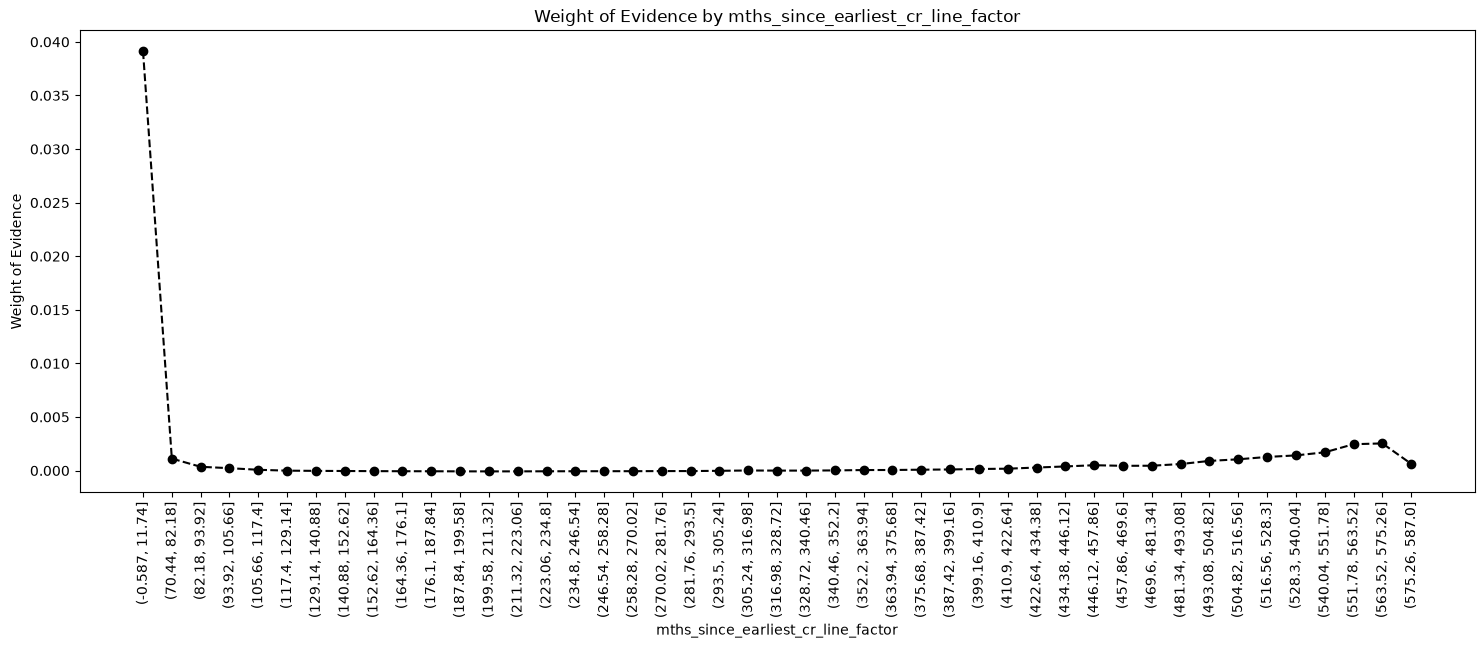

In [74]:
plot_by_woe(df_temp, 90)

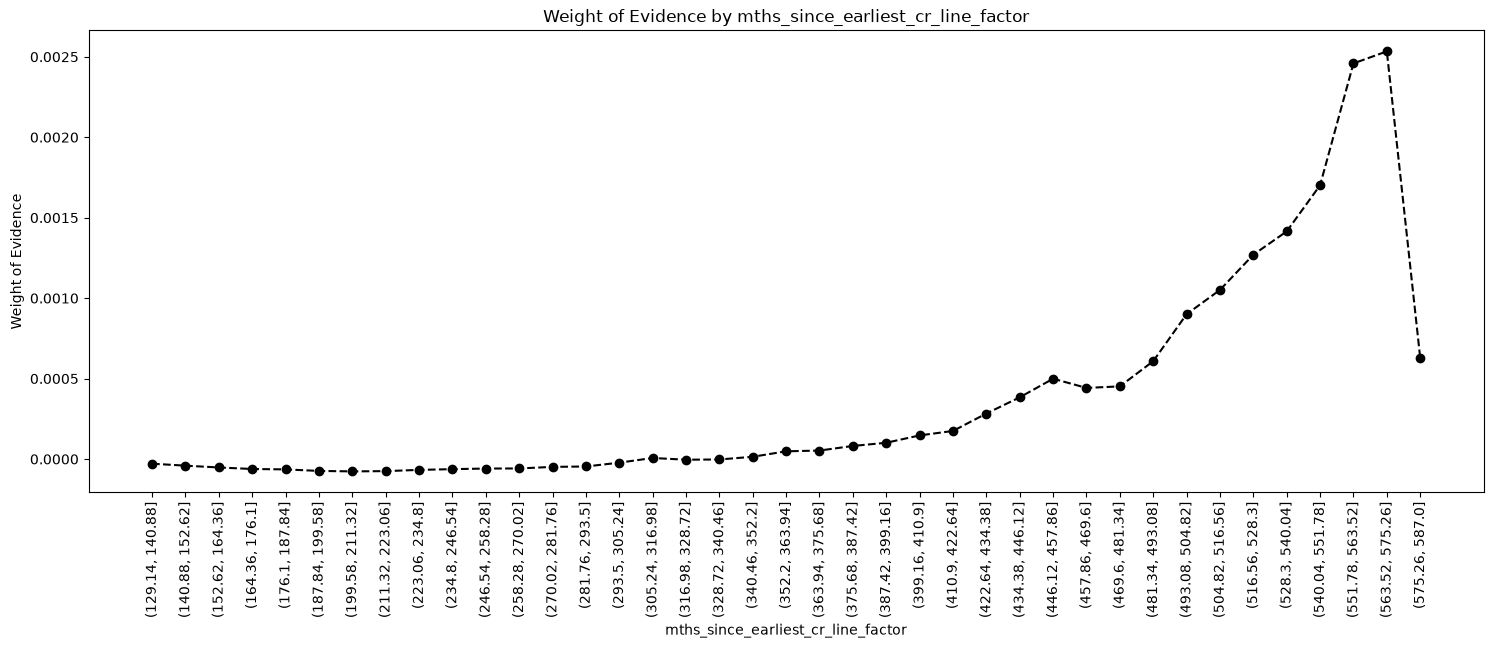

In [75]:
plot_by_woe(df_temp.iloc[6:, :], 90)

In [76]:
""" 
We create the following categories:
    < 140, 
    141 - 164, 
    165 - 247, 
    248 - 270, 
    271 - 352, 
    > 352
"""

df_inputs_prepr['mths_since_earliest_cr_line:<140'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140, 165)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:165-247'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(165, 248)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:248-270'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(248, 271)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:271-352'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(271, 353)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:>352'] = np.where(
    df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(353, int(df_inputs_prepr['mths_since_earliest_cr_line'].max()))), 
    1, 
    0
)


C:\Users\k\AppData\Local\Temp\ipykernel_16576\2974956651.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_earliest_cr_line:<140'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140)), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\2974956651.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140, 165)), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykerne

#### **delinq_2yrs** column

In [77]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'delinq_2yrs', df_targets_prepr)
df_temp

c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,delinq_2yrs,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,382983,0.890588,0.821350,341080.0,-341079.0,0.821252,0.821297,-0.000055,NaN,NaN,0.000007
1,1.0,56224,0.892679,0.120579,50190.0,-50189.0,0.120847,0.120852,-0.000038,0.002091,0.000017,0.000007
2,2.0,16310,0.888228,0.034979,14487.0,-14486.0,0.034882,0.034881,0.000011,0.004451,0.000049,0.000007
3,3.0,5684,0.885292,0.012190,5032.0,-5031.0,0.012116,0.012114,0.000141,0.002936,0.000130,0.000007
4,4.0,2378,0.896131,0.005100,2131.0,-2130.0,0.005131,0.005129,0.000412,0.010839,0.000271,0.000007
5,5.0,1236,0.888350,0.002651,1098.0,-1097.0,0.002644,0.002642,0.000853,0.007782,0.000442,0.000007
6,6.0,629,0.893482,0.001349,562.0,-561.0,0.001353,0.001351,0.001723,0.005132,0.000870,0.000007
7,7.0,346,0.872832,0.000742,302.0,-301.0,0.000727,0.000725,0.003259,0.020649,0.001536,0.000007
8,8.0,177,0.903955,0.000380,160.0,-159.0,0.000385,0.000383,0.006212,0.031122,0.002953,0.000007
9,9.0,111,0.900901,0.000238,100.0,-99.0,0.000241,0.000238,0.009993,0.003054,0.003781,0.000007


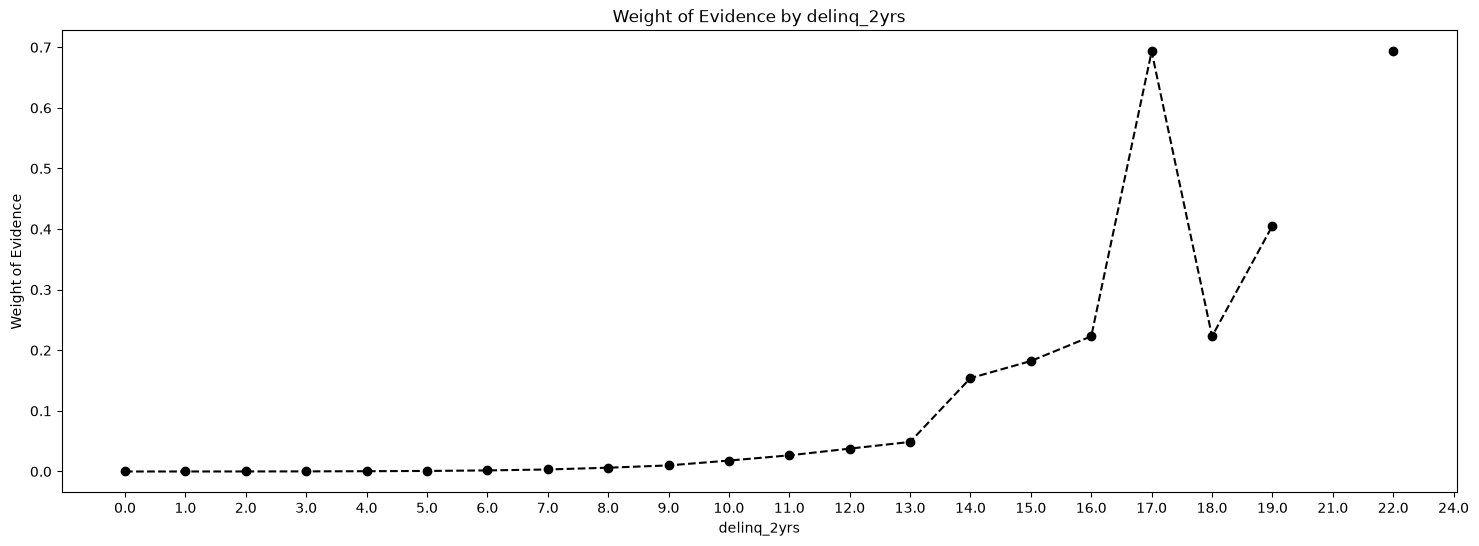

In [78]:
plot_by_woe(df_temp)

In [79]:
# Categories: 0, 1-3, >=4
df_inputs_prepr['delinq_2yrs:0'] = np.where((df_inputs_prepr['delinq_2yrs'] == 0), 1, 0)
df_inputs_prepr['delinq_2yrs:1-3'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 1) & (df_inputs_prepr['delinq_2yrs'] <= 3), 1, 0)
df_inputs_prepr['delinq_2yrs:>=4'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 9), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3997141776.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['delinq_2yrs:0'] = np.where((df_inputs_prepr['delinq_2yrs'] == 0), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3997141776.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['delinq_2yrs:1-3'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 1) & (df_inputs_prepr['delinq_2yrs'] <= 3), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3997141776.py:4: PerformanceWarning: DataFrame is 

#### **inq_last_6mths** column

In [80]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'inq_last_6mths', df_targets_prepr)
df_temp

c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,inq_last_6mths,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,241527,0.908735,0.517981,219484.0,-219483.0,0.528473,0.528507,-0.000063,NaN,NaN,-inf
1,1.0,130148,0.884439,0.279117,115108.0,-115107.0,0.277157,0.277173,-0.000059,0.024296,0.000004,-inf
2,2.0,57825,0.863606,0.124012,49938.0,-49937.0,0.120241,0.120246,-0.000047,0.020834,0.000011,-inf
3,3.0,25126,0.841001,0.053885,21131.0,-21130.0,0.050879,0.050880,-0.000020,0.022604,0.000027,-inf
4,4.0,7241,0.846982,0.015529,6133.0,-6132.0,0.014767,0.014766,0.000096,0.005981,0.000116,-inf
5,5.0,2768,0.828396,0.005936,2293.0,-2292.0,0.005521,0.005519,0.000369,0.018587,0.000273,-inf
6,6.0,1188,0.783670,0.002548,931.0,-930.0,0.002242,0.002239,0.001007,0.044726,0.000638,-inf
7,7.0,195,0.651282,0.000418,127.0,-126.0,0.000306,0.000303,0.007838,0.132388,0.006830,-inf
8,8.0,122,0.622951,0.000262,76.0,-75.0,0.000183,0.000181,0.013178,0.028331,0.005340,-inf
9,9.0,50,0.640000,0.000107,32.0,-31.0,0.000077,0.000075,0.031681,0.017049,0.018503,-inf


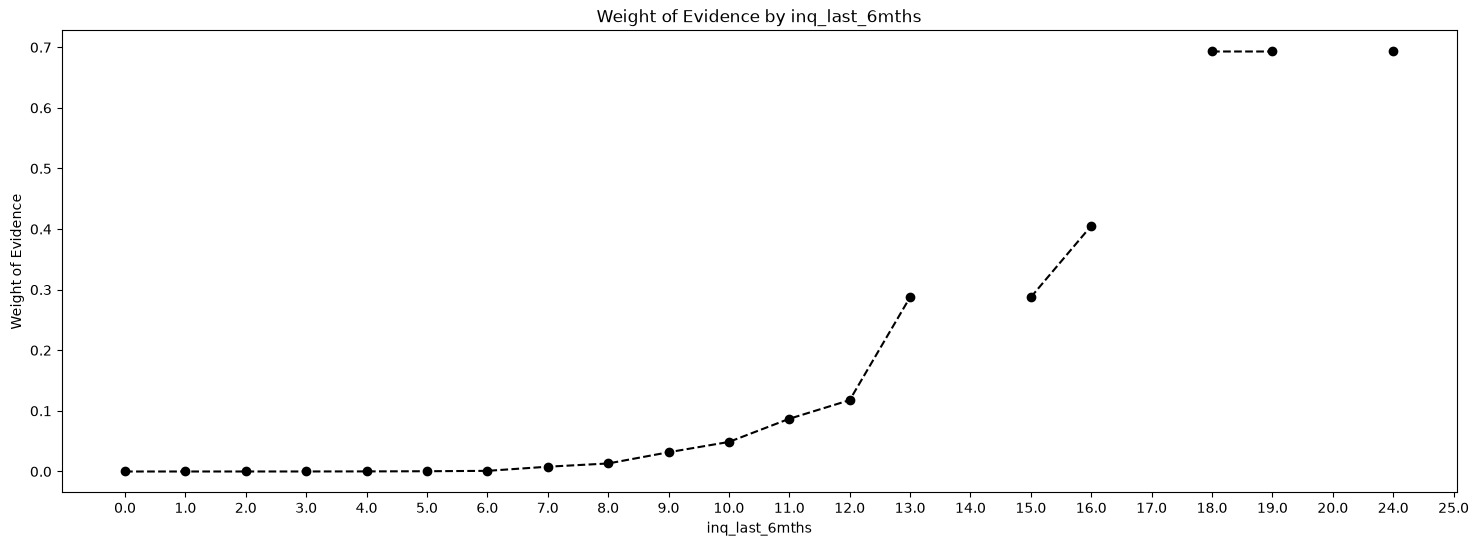

In [81]:
plot_by_woe(df_temp)

In [82]:
# Categories: 0, 1 - 2, 3 - 6, > 6
df_inputs_prepr['inq_last_6mths:0'] = np.where((df_inputs_prepr['inq_last_6mths'] == 0), 1, 0)
df_inputs_prepr['inq_last_6mths:1-2'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 1) & (df_inputs_prepr['inq_last_6mths'] <= 2), 1, 0)
df_inputs_prepr['inq_last_6mths:3-6'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 3) & (df_inputs_prepr['inq_last_6mths'] <= 6), 1, 0)
df_inputs_prepr['inq_last_6mths:>6'] = np.where((df_inputs_prepr['inq_last_6mths'] > 6), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\4129688625.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['inq_last_6mths:0'] = np.where((df_inputs_prepr['inq_last_6mths'] == 0), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\4129688625.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['inq_last_6mths:1-2'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 1) & (df_inputs_prepr['inq_last_6mths'] <= 2), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\4129688625.py:4: PerformanceWarning

#### **open_acc** column 

In [83]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'open_acc', df_targets_prepr)
df_temp

c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,open_acc,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,36,0.805556,0.000077,29.0,-28.0,0.000070,0.000067,0.034942,NaN,NaN,-inf
1,1.0,142,0.873239,0.000305,124.0,-123.0,0.000299,0.000296,0.007948,0.067684,0.026994,-inf
2,2.0,1790,0.844134,0.003839,1511.0,-1510.0,0.003638,0.003636,0.000513,0.029105,0.007435,-inf
3,3.0,5500,0.869455,0.011795,4782.0,-4781.0,0.011514,0.011513,0.000060,0.025320,0.000453,-inf
4,4.0,12588,0.891643,0.026996,11224.0,-11223.0,0.027025,0.027027,-0.000060,0.022188,0.000120,-inf
...,...,...,...,...,...,...,...,...,...,...,...,...
57,61.0,1,1.000000,0.000002,1.0,0.0,0.000002,-0.000000,NaN,0.000000,NaN,-inf
58,62.0,1,1.000000,0.000002,1.0,0.0,0.000002,-0.000000,NaN,0.000000,NaN,-inf
59,75.0,1,1.000000,0.000002,1.0,0.0,0.000002,-0.000000,NaN,0.000000,NaN,-inf
60,76.0,2,0.000000,0.000004,0.0,1.0,0.000000,-0.000002,-inf,1.000000,NaN,-inf


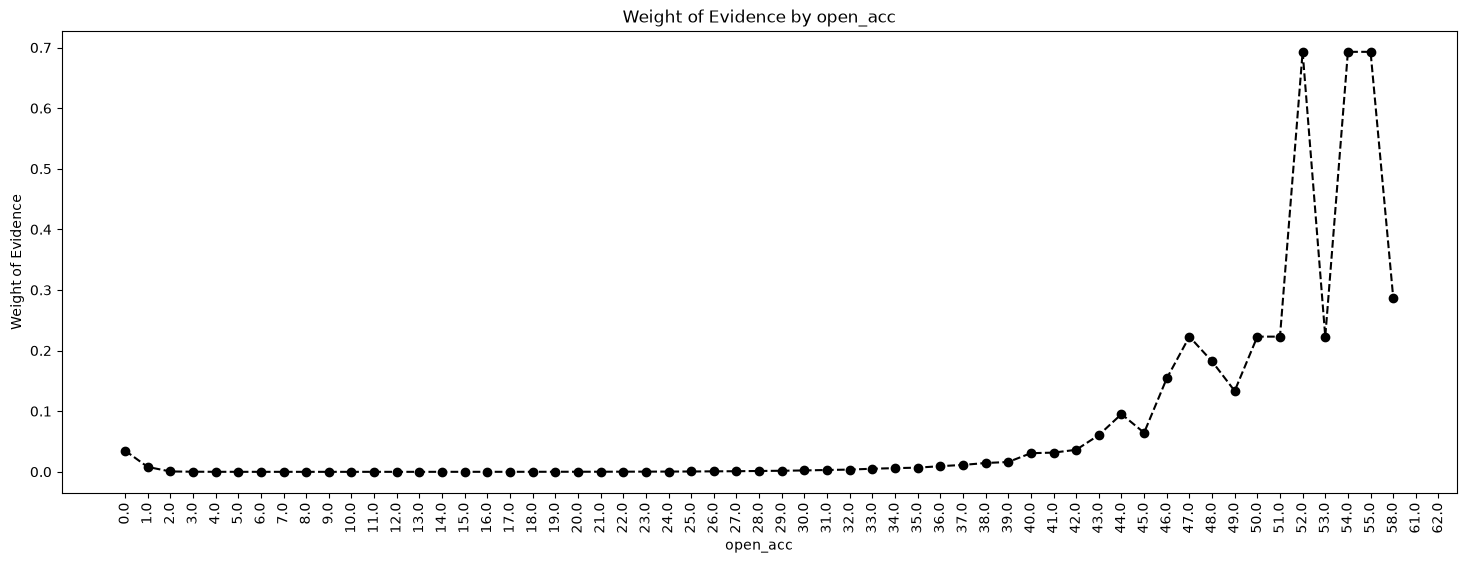

In [84]:
plot_by_woe(df_temp, 90)

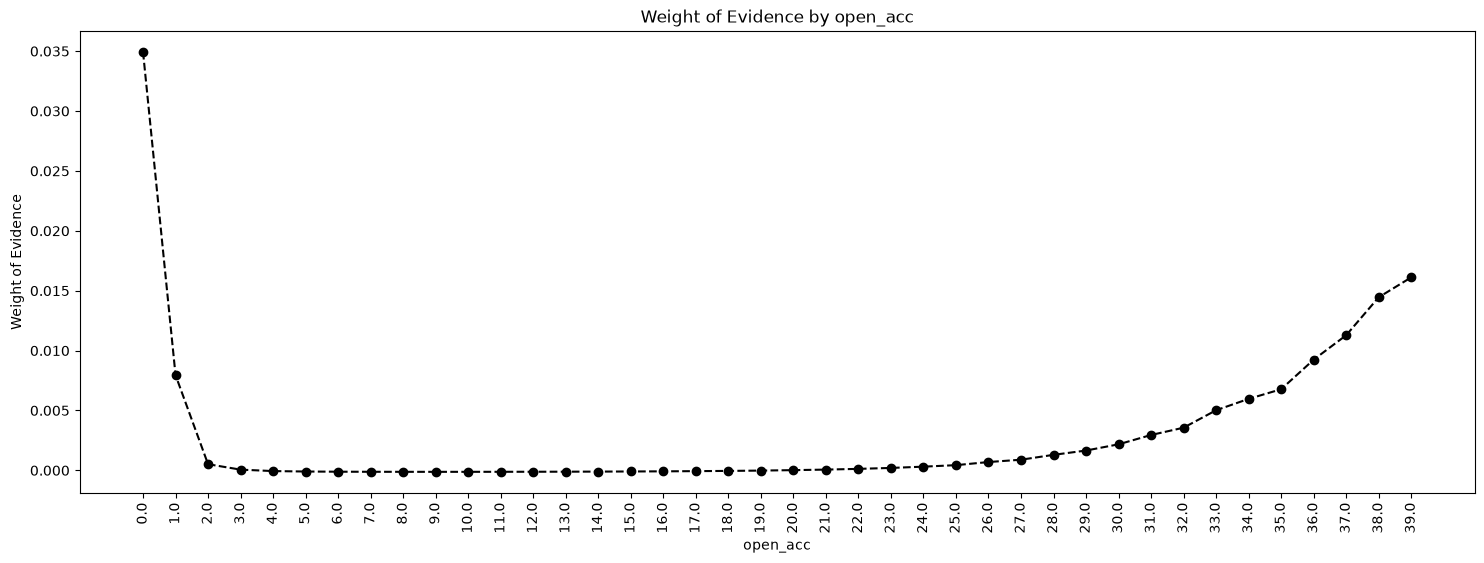

In [85]:
plot_by_woe(df_temp.iloc[ : 40, :], 90)

In [86]:
# Categories: '0', '1-3', '4-12', '13-17', '18-22', '23-25', '26-30', '>30'
df_inputs_prepr['open_acc:0'] = np.where((df_inputs_prepr['open_acc'] == 0), 1, 0)
df_inputs_prepr['open_acc:1-3'] = np.where((df_inputs_prepr['open_acc'] >= 1) & (df_inputs_prepr['open_acc'] <= 3), 1, 0)
df_inputs_prepr['open_acc:4-12'] = np.where((df_inputs_prepr['open_acc'] >= 4) & (df_inputs_prepr['open_acc'] <= 12), 1, 0)
df_inputs_prepr['open_acc:13-17'] = np.where((df_inputs_prepr['open_acc'] >= 13) & (df_inputs_prepr['open_acc'] <= 17), 1, 0)
df_inputs_prepr['open_acc:18-22'] = np.where((df_inputs_prepr['open_acc'] >= 18) & (df_inputs_prepr['open_acc'] <= 22), 1, 0)
df_inputs_prepr['open_acc:23-25'] = np.where((df_inputs_prepr['open_acc'] >= 23) & (df_inputs_prepr['open_acc'] <= 25), 1, 0)
df_inputs_prepr['open_acc:26-30'] = np.where((df_inputs_prepr['open_acc'] >= 26) & (df_inputs_prepr['open_acc'] <= 30), 1, 0)
df_inputs_prepr['open_acc:>=31'] = np.where((df_inputs_prepr['open_acc'] >= 31), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\1163336257.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['open_acc:0'] = np.where((df_inputs_prepr['open_acc'] == 0), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\1163336257.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['open_acc:1-3'] = np.where((df_inputs_prepr['open_acc'] >= 1) & (df_inputs_prepr['open_acc'] <= 3), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\1163336257.py:4: PerformanceWarning: DataFrame is highly fragment

#### **pub_rec** column 

In [87]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'pub_rec', df_targets_prepr)
df_temp

c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,pub_rec,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,404922,0.889789,0.868400,360295.0,-360294.0,0.867518,0.867570,-0.000060,NaN,NaN,0.000006
1,1.0,53051,0.894969,0.113774,47479.0,-47478.0,0.114320,0.114325,-0.000042,0.005180,0.000018,0.000006
2,2.0,5624,0.903450,0.012061,5081.0,-5080.0,0.012234,0.012232,0.000134,0.008481,0.000176,0.000006
3,3.0,1611,0.916201,0.003455,1476.0,-1475.0,0.003554,0.003552,0.000615,0.012752,0.000481,0.000006
4,4.0,520,0.909615,0.001115,473.0,-472.0,0.001139,0.001137,0.002054,0.006586,0.001439,0.000006
5,5.0,276,0.909420,0.000592,251.0,-250.0,0.000604,0.000602,0.003929,0.000195,0.001876,0.000006
6,6.0,136,0.926471,0.000292,126.0,-125.0,0.000303,0.000301,0.007906,0.017050,0.003976,0.000006
7,7.0,62,0.919355,0.000133,57.0,-56.0,0.000137,0.000135,0.017637,0.007116,0.009731,0.000006
8,8.0,29,0.965517,0.000062,28.0,-27.0,0.000067,0.000065,0.036305,0.046162,0.018668,0.000006
9,9.0,16,0.812500,0.000034,13.0,-12.0,0.000031,0.000029,0.079980,0.153017,0.043675,0.000006


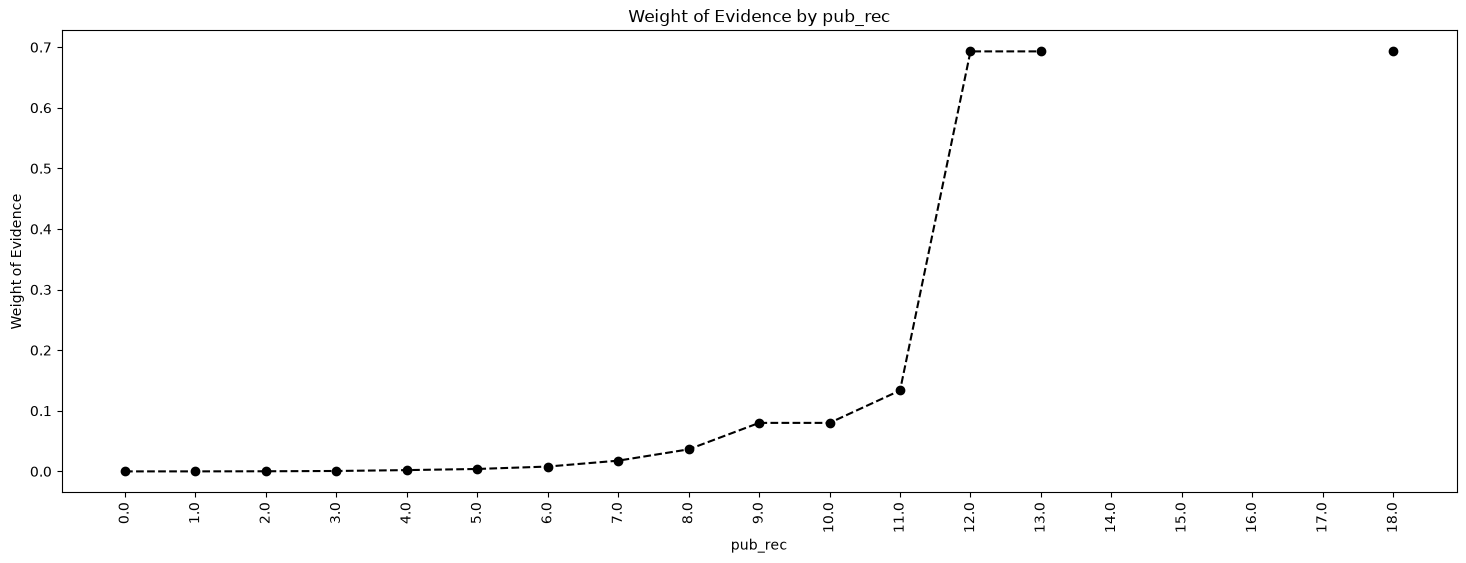

In [88]:
plot_by_woe(df_temp, 90)

In [89]:
# Categories '0-2', '3-4', '>=5'
df_inputs_prepr['pub_rec:0-2'] = np.where((df_inputs_prepr['pub_rec'] >= 0) & (df_inputs_prepr['pub_rec'] <= 2), 1, 0)
df_inputs_prepr['pub_rec:3-4'] = np.where((df_inputs_prepr['pub_rec'] >= 3) & (df_inputs_prepr['pub_rec'] <= 4), 1, 0)
df_inputs_prepr['pub_rec:>=5'] = np.where((df_inputs_prepr['pub_rec'] >= 5), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3619862568.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['pub_rec:0-2'] = np.where((df_inputs_prepr['pub_rec'] >= 0) & (df_inputs_prepr['pub_rec'] <= 2), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3619862568.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['pub_rec:3-4'] = np.where((df_inputs_prepr['pub_rec'] >= 3) & (df_inputs_prepr['pub_rec'] <= 4), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3619862568.py:4: PerformanceWarn

#### **total_acc** column 

In [90]:
df_inputs_prepr['total_acc_factor'] = pd.cut(df_inputs_prepr['total_acc'], 50)

df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_acc_factor', df_targets_prepr)
df_temp

C:\Users\k\AppData\Local\Temp\ipykernel_16576\757034901.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_acc_factor'] = pd.cut(df_inputs_prepr['total_acc'], 50)
c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,total_acc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.156, 3.12]",584,0.803082,0.001252,469.0,-468.0,0.001129,0.001127,0.002041,NaN,NaN,0.000005
1,"(3.12, 6.24]",7503,0.861922,0.016091,6467.0,-6466.0,0.015571,0.015570,0.000061,0.058840,1.979829e-03,0.000005
2,"(6.24, 9.36]",18762,0.872881,0.040237,16377.0,-16376.0,0.039433,0.039434,-0.000033,0.010959,9.358005e-05,0.000005
3,"(9.36, 12.48]",31457,0.879995,0.067463,27682.0,-27681.0,0.066653,0.066657,-0.000058,0.007114,2.493790e-05,0.000005
4,"(12.48, 15.6]",41940,0.882666,0.089945,37019.0,-37018.0,0.089134,0.089140,-0.000067,0.002671,9.111690e-06,0.000005
5,"(15.6, 18.72]",48554,0.887857,0.104129,43109.0,-43108.0,0.103798,0.103805,-0.000071,0.005191,3.816239e-06,0.000005
6,"(18.72, 21.84]",50869,0.887712,0.109094,45157.0,-45156.0,0.108729,0.108737,-0.000072,0.000145,1.052075e-06,0.000005
7,"(21.84, 24.96]",50134,0.891750,0.107518,44707.0,-44706.0,0.107645,0.107653,-0.000072,0.004039,2.229059e-07,0.000005
8,"(24.96, 28.08]",59229,0.895338,0.127023,53030.0,-53029.0,0.127686,0.127695,-0.000075,0.003588,3.510684e-06,0.000005
9,"(28.08, 31.2]",37156,0.897136,0.079685,33334.0,-33333.0,0.080262,0.080267,-0.000064,0.001798,1.114242e-05,0.000005


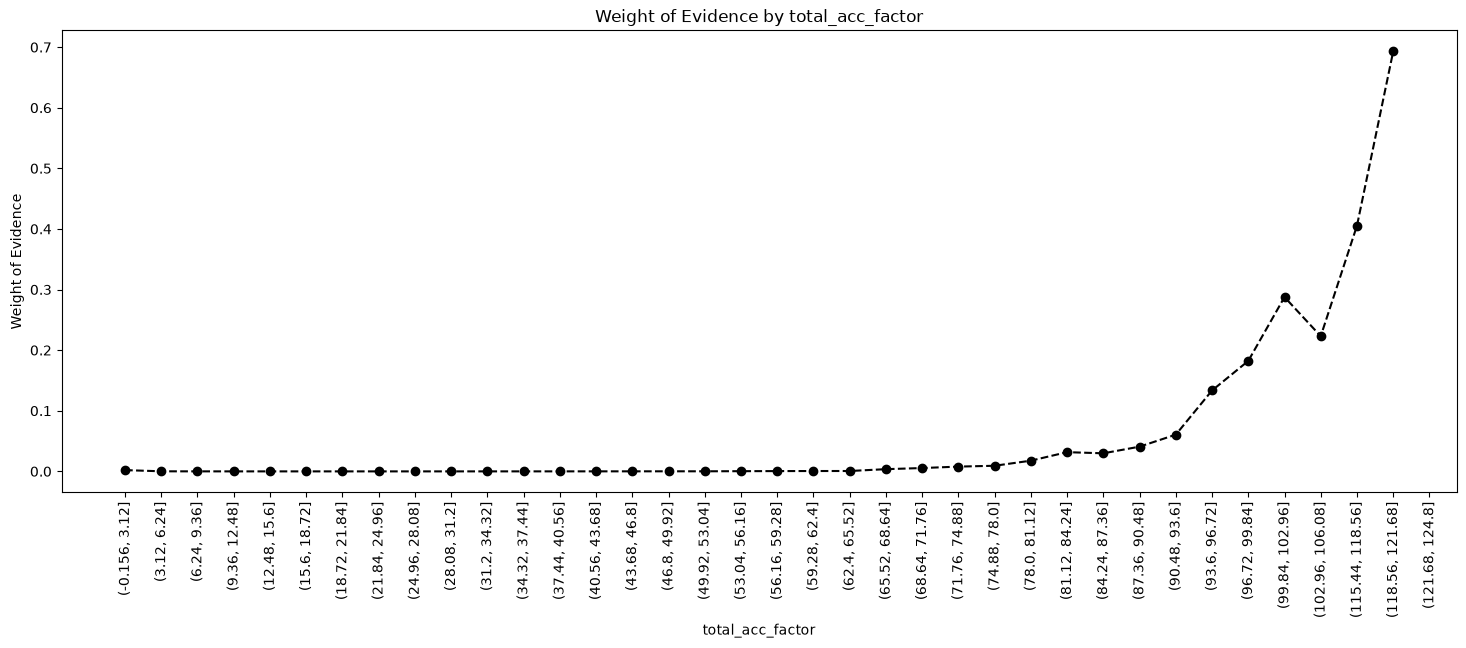

In [91]:
plot_by_woe(df_temp, 90)

In [92]:
# Categories: '<=27', '28-51', '>51'
df_inputs_prepr['total_acc:<=27'] = np.where((df_inputs_prepr['total_acc'] <= 27), 1, 0)
df_inputs_prepr['total_acc:28-51'] = np.where((df_inputs_prepr['total_acc'] >= 28) & (df_inputs_prepr['total_acc'] <= 51), 1, 0)
df_inputs_prepr['total_acc:>=52'] = np.where((df_inputs_prepr['total_acc'] >= 52), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3953242836.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_acc:<=27'] = np.where((df_inputs_prepr['total_acc'] <= 27), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3953242836.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_acc:28-51'] = np.where((df_inputs_prepr['total_acc'] >= 28) & (df_inputs_prepr['total_acc'] <= 51), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3953242836.py:4: PerformanceWarning: DataFrame is hi

#### **acc_now_delinq** column 

In [93]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'acc_now_delinq', df_targets_prepr)
df_temp

c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,acc_now_delinq,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,464553,0.890684,0.996286,413770.0,-413769.0,0.996275,0.996287,-0.000012,NaN,NaN,0.000001
1,1.0,1623,0.893407,0.003481,1450.0,-1449.0,0.003491,0.003489,0.000675,0.002723,0.000687,0.000001
2,2.0,92,0.902174,0.000197,83.0,-82.0,0.000200,0.000197,0.012107,0.008767,0.011431,0.000001
3,3.0,11,0.818182,0.000024,9.0,-8.0,0.000022,0.000019,0.117769,0.083992,0.105662,0.000001
4,4.0,4,1.000000,0.000009,4.0,-3.0,0.000010,0.000007,0.287668,0.181818,0.169899,0.000001
5,5.0,2,0.500000,0.000004,1.0,0.0,0.000002,-0.000000,NaN,0.500000,NaN,0.000001


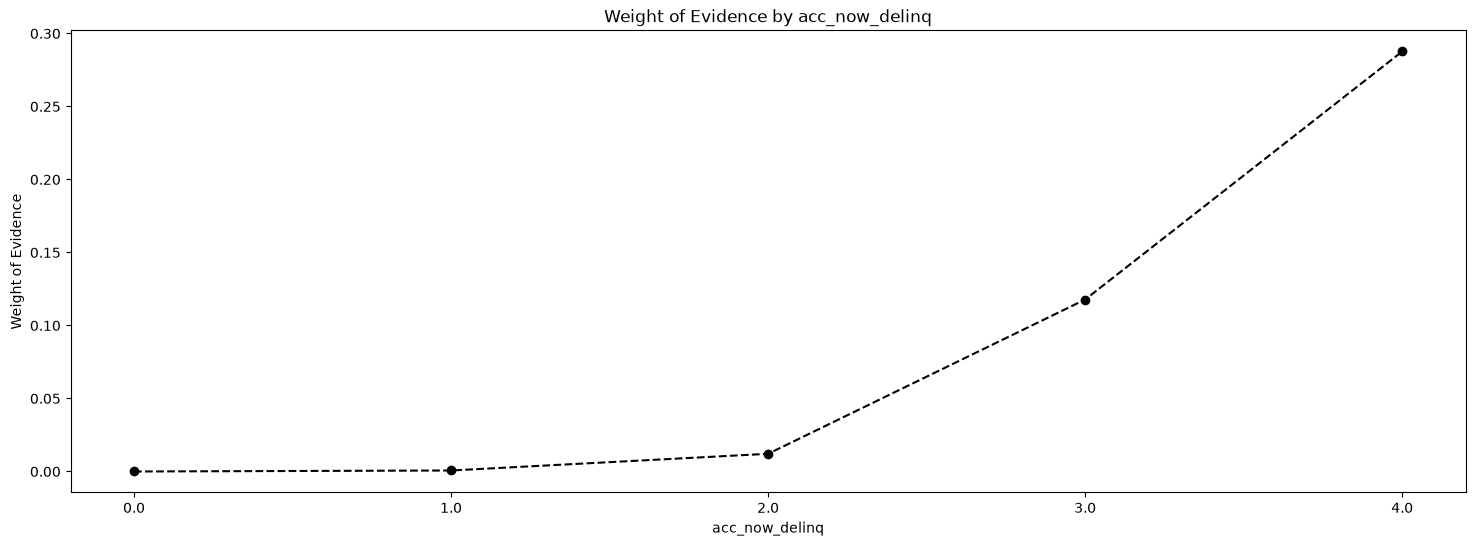

In [94]:
plot_by_woe(df_temp)

In [95]:
# Categories: '0', '>=1'
df_inputs_prepr['acc_now_delinq:0'] = np.where((df_inputs_prepr['acc_now_delinq'] == 0), 1, 0)
df_inputs_prepr['acc_now_delinq:>=1'] = np.where((df_inputs_prepr['acc_now_delinq'] >= 1), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\2448457627.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['acc_now_delinq:0'] = np.where((df_inputs_prepr['acc_now_delinq'] == 0), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\2448457627.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['acc_now_delinq:>=1'] = np.where((df_inputs_prepr['acc_now_delinq'] >= 1), 1, 0)


#### **total_rev_hi_lim** column 

In [96]:
df_inputs_prepr['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr['total_rev_hi_lim'], 2000)

df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_rev_hi_lim_factor', df_targets_prepr)
df_temp

C:\Users\k\AppData\Local\Temp\ipykernel_16576\977412026.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr['total_rev_hi_lim'], 2000)
c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,total_rev_hi_lim_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-9999.999, 5000.0]",24313,0.865340,0.052142,21039.0,-21038.0,0.050658,0.050673,-0.000309,NaN,NaN,-inf
1,"(5000.0, 9999.999]",65938,0.875565,0.141411,57733.0,-57732.0,0.139009,0.139057,-0.000339,0.010225,0.000030,-inf
2,"(9999.999, 14999.998]",74357,0.880307,0.159467,65457.0,-65456.0,0.157607,0.157661,-0.000341,0.004742,0.000002,-inf
3,"(14999.998, 19999.998]",64259,0.878103,0.137811,56426.0,-56425.0,0.135862,0.135909,-0.000339,0.002204,0.000002,-inf
4,"(19999.998, 24999.997]",51995,0.886855,0.111509,46112.0,-46111.0,0.111028,0.111066,-0.000335,0.008752,0.000004,-inf
...,...,...,...,...,...,...,...,...,...,...,...,...
143,"(1309999.869, 1314999.868]",1,1.000000,0.000002,1.0,0.0,0.000002,-0.000000,NaN,0.000000,NaN,-inf
144,"(1504999.85, 1509999.849]",1,1.000000,0.000002,1.0,0.0,0.000002,-0.000000,NaN,0.000000,NaN,-inf
145,"(1994999.8, 1999999.8]",1,0.000000,0.000002,0.0,1.0,0.000000,-0.000002,-inf,1.000000,NaN,-inf
146,"(2009999.799, 2014999.798]",1,1.000000,0.000002,1.0,0.0,0.000002,-0.000000,NaN,1.000000,NaN,-inf


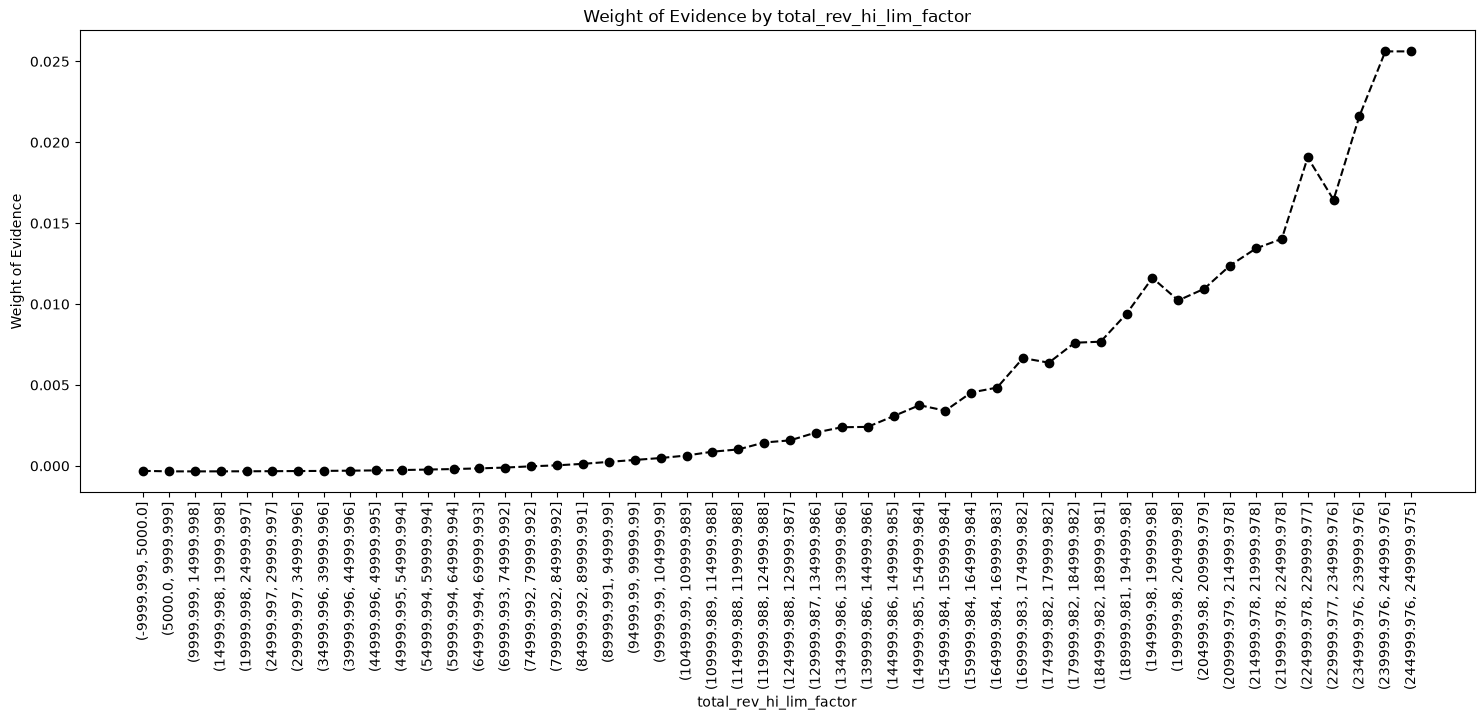

In [97]:
plot_by_woe(df_temp.iloc[: 50, : ], 90)

In [98]:
# Categories
# '<=5K', '5K-10K', '10K-20K', '20K-30K', '30K-40K', '40K-55K', '55K-95K', '>95K'
df_inputs_prepr['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] <= 5000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 5000) & (df_inputs_prepr['total_rev_hi_lim'] <= 10000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:10K-20K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 10000) & (df_inputs_prepr['total_rev_hi_lim'] <= 20000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:20K-30K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 20000) & (df_inputs_prepr['total_rev_hi_lim'] <= 30000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:30K-40K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 30000) & (df_inputs_prepr['total_rev_hi_lim'] <= 40000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:40K-55K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 40000) & (df_inputs_prepr['total_rev_hi_lim'] <= 55000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:55K-95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 55000) & (df_inputs_prepr['total_rev_hi_lim'] <= 95000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:>95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 95000), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\429332966.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] <= 5000), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\429332966.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 5000) & (df_inputs_prepr['total_rev_hi_lim'] <= 10000), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\429332966.py

#### **installment** column

In [99]:
df_inputs_prepr['installment_factor'] = pd.cut(df_inputs_prepr['installment'], 50)

df_temp = woe_ordered_continuous(df_inputs_prepr, 'installment_factor', df_targets_prepr)
df_temp

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3011647184.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['installment_factor'] = pd.cut(df_inputs_prepr['installment'], 50)


,installment_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(14.276, 43.556]",2297,0.898999,0.004926,2065.0,-2064.0,0.004972,0.004970,0.000364,NaN,NaN,1.969129e-07
1,"(43.556, 71.443]",6090,0.898851,0.013061,5474.0,-5473.0,0.013180,0.013179,0.000062,0.000148,3.016803e-04,1.969129e-07
2,"(71.443, 99.329]",8554,0.893617,0.018345,7644.0,-7643.0,0.018405,0.018405,0.000010,0.005234,5.186834e-05,1.969129e-07
3,"(99.329, 127.216]",11440,0.891434,0.024534,10198.0,-10197.0,0.024555,0.024555,-0.000022,0.002183,3.276687e-05,1.969129e-07
4,"(127.216, 155.102]",12648,0.894450,0.027125,11313.0,-11312.0,0.027239,0.027240,-0.000032,0.003016,9.665461e-06,1.969129e-07
5,"(155.102, 182.988]",20953,0.894908,0.044936,18751.0,-18750.0,0.045149,0.045152,-0.000067,0.000458,3.506588e-05,1.969129e-07
6,"(182.988, 210.875]",21342,0.904836,0.045770,19311.0,-19310.0,0.046497,0.046500,-0.000069,0.009928,1.546613e-06,1.969129e-07
7,"(210.875, 238.761]",18804,0.900606,0.040327,16935.0,-16934.0,0.040776,0.040779,-0.000061,0.004229,7.265751e-06,1.969129e-07
8,"(238.761, 266.648]",23532,0.901028,0.050467,21203.0,-21202.0,0.051053,0.051056,-0.000073,0.000422,1.188680e-05,1.969129e-07
9,"(266.648, 294.534]",25075,0.890728,0.053776,22335.0,-22334.0,0.053778,0.053782,-0.000076,0.010301,2.390469e-06,1.969129e-07


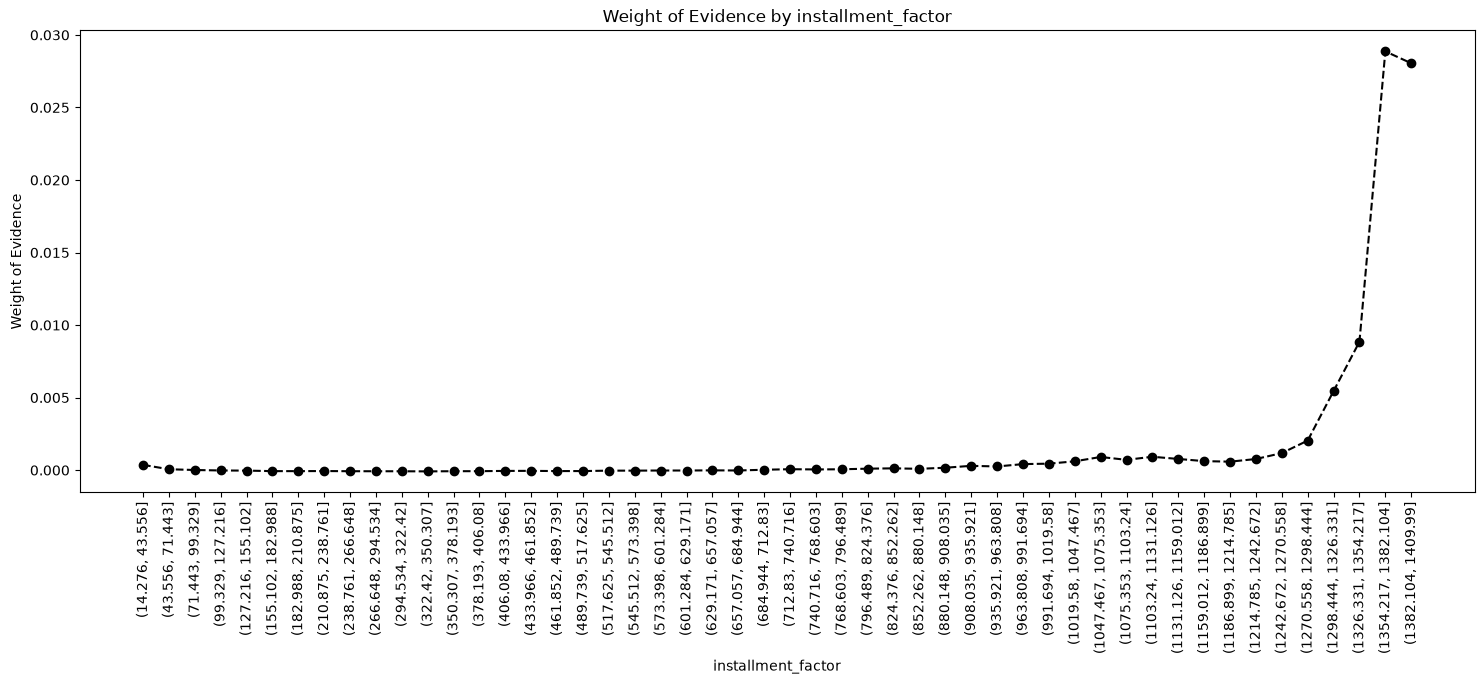

In [100]:
plot_by_woe(df_temp, 90)

#### **annual_inc** column 

In [101]:
df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr['annual_inc'], 50)

df_temp = woe_ordered_continuous(df_inputs_prepr, 'annual_inc_factor', df_targets_prepr)
df_temp

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3639866103.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr['annual_inc'], 50)
c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-5602.104, 151858.08]",445843,0.888999,0.956160,396354.0,-396353.0,0.954341,0.954389,-0.000050,NaN,NaN,0.000007
1,"(151858.08, 301820.16]",18425,0.926947,0.039514,17079.0,-17078.0,0.041123,0.041123,0.000006,0.037948,0.000056,0.000007
2,"(301820.16, 451782.24]",1368,0.933480,0.002934,1277.0,-1276.0,0.003075,0.003073,0.000730,0.006532,0.000725,0.000007
3,"(451782.24, 601744.32]",372,0.940860,0.000798,350.0,-349.0,0.000843,0.000840,0.002808,0.007381,0.002078,0.000007
4,"(601744.32, 751706.4]",115,0.904348,0.000247,104.0,-103.0,0.000250,0.000248,0.009609,0.036512,0.006801,0.000007
5,"(751706.4, 901668.48]",73,0.904110,0.000157,66.0,-65.0,0.000159,0.000157,0.015214,0.000238,0.005606,0.000007
6,"(901668.48, 1051630.56]",33,0.969697,0.000071,32.0,-31.0,0.000077,0.000075,0.031696,0.065587,0.016481,0.000007
7,"(1051630.56, 1201592.64]",21,1.000000,0.000045,21.0,-20.0,0.000051,0.000048,0.048737,0.030303,0.017041,0.000007
8,"(1201592.64, 1351554.72]",10,0.900000,0.000021,9.0,-8.0,0.000022,0.000019,0.117730,0.100000,0.068993,0.000007
9,"(1351554.72, 1501516.8]",6,1.000000,0.000013,6.0,-5.0,0.000014,0.000012,0.182269,0.100000,0.064539,0.000007


In [102]:
df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr['annual_inc'], 100)

In [103]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'annual_inc_factor', df_targets_prepr)
df_temp

c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-5602.104, 76877.04]",306443,0.877357,0.657201,268860.0,-268859.0,0.647361,0.647412,-0.000078,NaN,NaN,0.000009
1,"(76877.04, 151858.08]",139400,0.914591,0.298959,127494.0,-127493.0,0.306980,0.307003,-0.000074,0.037234,0.000004,0.000009
2,"(151858.08, 226839.12]",14866,0.926880,0.031882,13779.0,-13778.0,0.033177,0.033177,-0.000009,0.012289,0.000065,0.000009
3,"(226839.12, 301820.16]",3559,0.927227,0.007633,3300.0,-3299.0,0.007946,0.007944,0.000221,0.000347,0.000230,0.000009
4,"(301820.16, 376801.2]",867,0.929642,0.001859,806.0,-805.0,0.001941,0.001938,0.001160,0.002416,0.000938,0.000009
5,"(376801.2, 451782.24]",501,0.940120,0.001074,471.0,-470.0,0.001134,0.001132,0.002044,0.010477,0.000884,0.000009
6,"(451782.24, 526763.28]",232,0.952586,0.000498,221.0,-220.0,0.000532,0.000530,0.004453,0.012466,0.002410,0.000009
7,"(526763.28, 601744.32]",140,0.921429,0.000300,129.0,-128.0,0.000311,0.000308,0.007700,0.031158,0.003247,0.000009
8,"(601744.32, 676725.36]",55,0.890909,0.000118,49.0,-48.0,0.000118,0.000116,0.020537,0.030519,0.012837,0.000009
9,"(676725.36, 751706.4]",60,0.916667,0.000129,55.0,-54.0,0.000132,0.000130,0.018267,0.025758,0.002270,0.000009


In [104]:
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['annual_inc'] <= 140000, : ]

In [105]:
df_inputs_prepr_temp["annual_inc_factor"] = pd.cut(df_inputs_prepr_temp['annual_inc'], 50)

df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'annual_inc_factor', df_targets_prepr[df_inputs_prepr_temp.index])
df_temp

,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(1757.896, 4658.08]",15,0.800000,0.000034,12.0,-11.0,0.000031,0.000028,0.086883,NaN,NaN,3.211388e-07
1,"(4658.08, 7420.16]",46,0.782609,0.000105,36.0,-35.0,0.000092,0.000090,0.028043,0.017391,0.058841,3.211388e-07
2,"(7420.16, 10182.24]",371,0.857143,0.000846,318.0,-317.0,0.000816,0.000813,0.003021,0.074534,0.025021,3.211388e-07
3,"(10182.24, 12944.32]",675,0.816296,0.001538,551.0,-550.0,0.001413,0.001411,0.001688,0.040847,0.001333,3.211388e-07
4,"(12944.32, 15706.4]",1517,0.834542,0.003458,1266.0,-1265.0,0.003248,0.003245,0.000662,0.018246,0.001026,3.211388e-07
5,"(15706.4, 18468.48]",1909,0.844421,0.004351,1612.0,-1611.0,0.004135,0.004133,0.000492,0.009879,0.000170,3.211388e-07
6,"(18468.48, 21230.56]",3678,0.851550,0.008383,3132.0,-3131.0,0.008034,0.008033,0.000191,0.007129,0.000301,3.211388e-07
7,"(21230.56, 23992.64]",3200,0.845625,0.007293,2706.0,-2705.0,0.006941,0.006940,0.000241,0.005925,0.000050,3.211388e-07
8,"(23992.64, 26754.72]",8833,0.851240,0.020132,7519.0,-7518.0,0.019288,0.019288,0.000005,0.005615,0.000237,3.211388e-07
9,"(26754.72, 29516.8]",7008,0.856450,0.015973,6002.0,-6001.0,0.015396,0.015396,0.000038,0.005210,0.000034,3.211388e-07


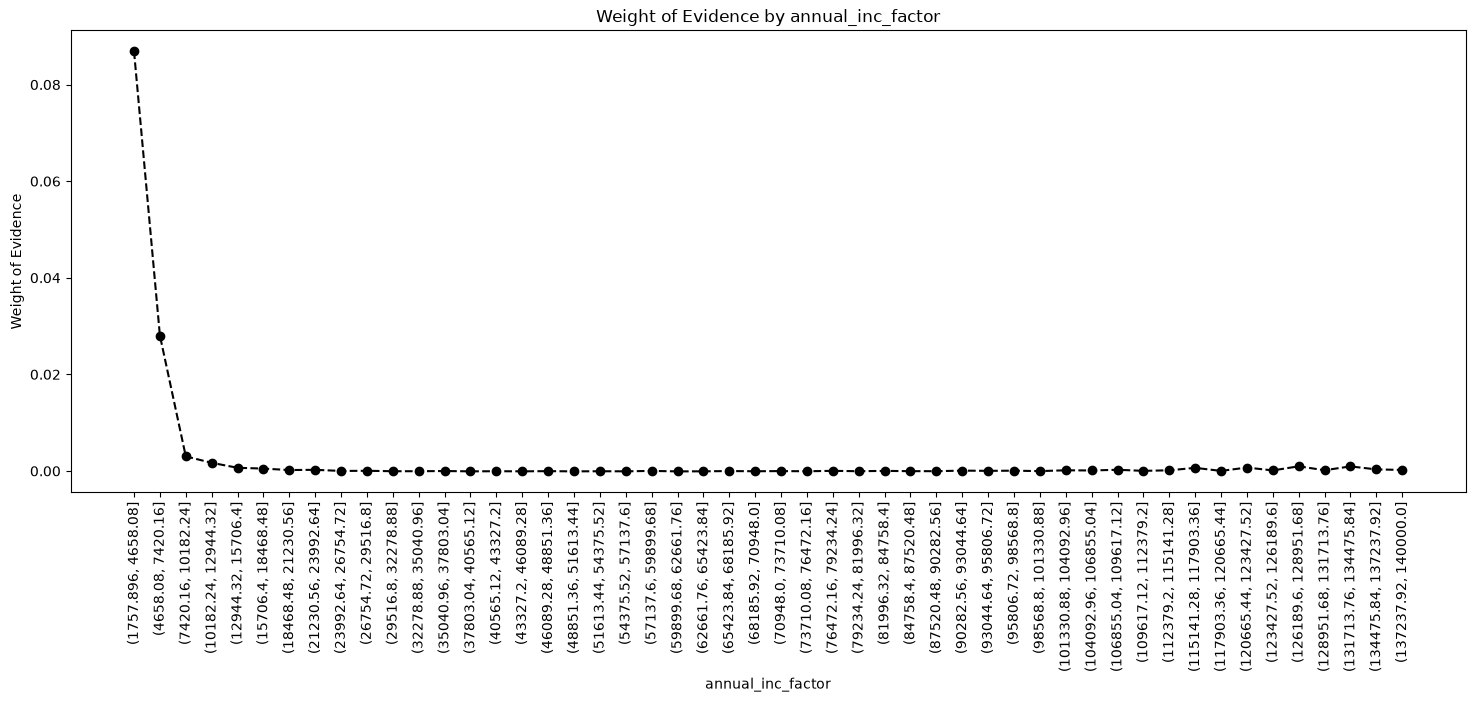

In [106]:
plot_by_woe(df_temp, 90)

In [107]:
# WoE is monotonically decreasing with income, so we split income in 10 equal categories, each with width of 15k.
df_inputs_prepr['annual_inc:<20K'] = np.where((df_inputs_prepr['annual_inc'] <= 20000), 1, 0)
df_inputs_prepr['annual_inc:20K-30K'] = np.where((df_inputs_prepr['annual_inc'] > 20000) & (df_inputs_prepr['annual_inc'] <= 30000), 1, 0)
df_inputs_prepr['annual_inc:30K-40K'] = np.where((df_inputs_prepr['annual_inc'] > 30000) & (df_inputs_prepr['annual_inc'] <= 40000), 1, 0)
df_inputs_prepr['annual_inc:40K-50K'] = np.where((df_inputs_prepr['annual_inc'] > 40000) & (df_inputs_prepr['annual_inc'] <= 50000), 1, 0)
df_inputs_prepr['annual_inc:50K-60K'] = np.where((df_inputs_prepr['annual_inc'] > 50000) & (df_inputs_prepr['annual_inc'] <= 60000), 1, 0)
df_inputs_prepr['annual_inc:60K-70K'] = np.where((df_inputs_prepr['annual_inc'] > 60000) & (df_inputs_prepr['annual_inc'] <= 70000), 1, 0)
df_inputs_prepr['annual_inc:70K-80K'] = np.where((df_inputs_prepr['annual_inc'] > 70000) & (df_inputs_prepr['annual_inc'] <= 80000), 1, 0)
df_inputs_prepr['annual_inc:80K-90K'] = np.where((df_inputs_prepr['annual_inc'] > 80000) & (df_inputs_prepr['annual_inc'] <= 90000), 1, 0)
df_inputs_prepr['annual_inc:90K-100K'] = np.where((df_inputs_prepr['annual_inc'] > 90000) & (df_inputs_prepr['annual_inc'] <= 100000), 1, 0)
df_inputs_prepr['annual_inc:100K-120K'] = np.where((df_inputs_prepr['annual_inc'] > 100000) & (df_inputs_prepr['annual_inc'] <= 120000), 1, 0)
df_inputs_prepr['annual_inc:120K-140K'] = np.where((df_inputs_prepr['annual_inc'] > 120000) & (df_inputs_prepr['annual_inc'] <= 140000), 1, 0)
df_inputs_prepr['annual_inc:>140K'] = np.where((df_inputs_prepr['annual_inc'] > 140000), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3226331627.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc:<20K'] = np.where((df_inputs_prepr['annual_inc'] <= 20000), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3226331627.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc:20K-30K'] = np.where((df_inputs_prepr['annual_inc'] > 20000) & (df_inputs_prepr['annual_inc'] <= 30000), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3226331627.py:4: PerformanceWarning: 

#### **mths_since_last_delinq** column 

In [108]:
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_delinq'])]

df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'mths_since_last_delinq_factor', df_targets_prepr[df_inputs_prepr_temp.index])

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3151333083.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)
c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


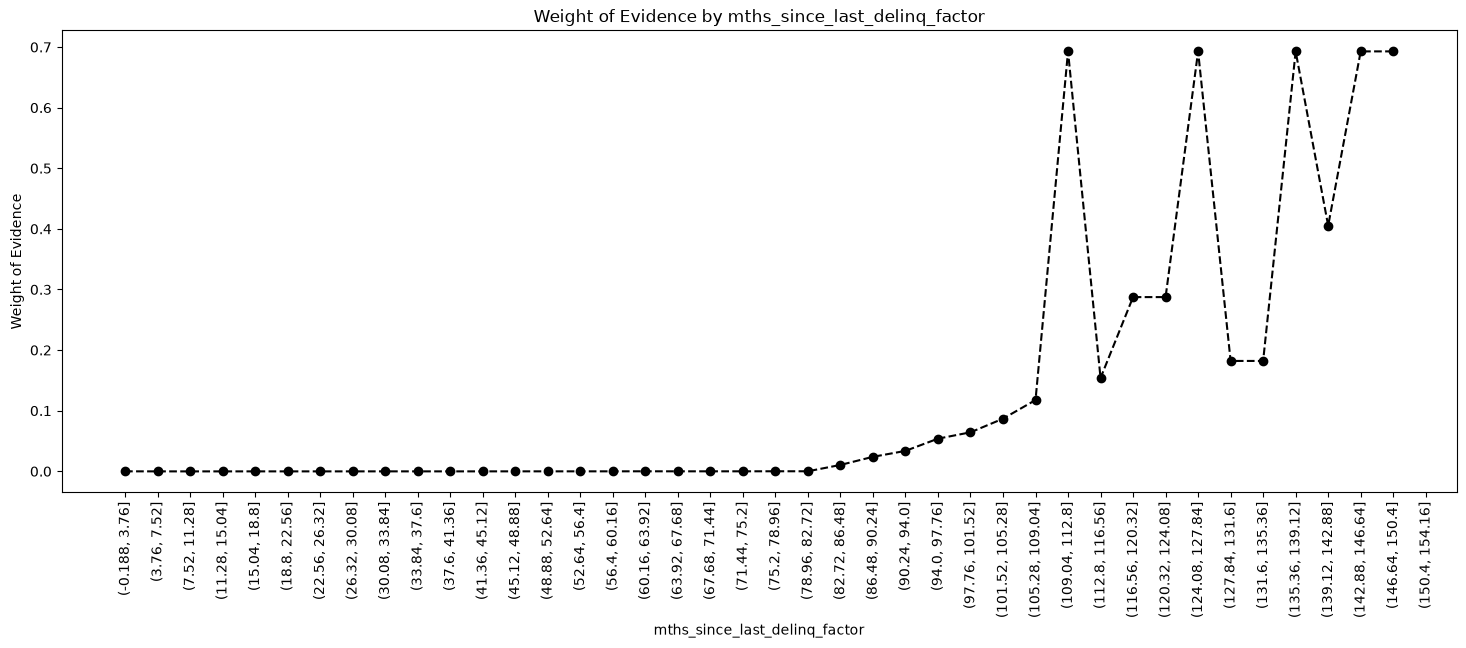

In [109]:
plot_by_woe(df_temp, 90)

In [110]:
# Categories: Missing, 0-3, 4-30, 31-56, >=57
df_inputs_prepr['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr['mths_since_last_delinq'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 0) & (df_inputs_prepr['mths_since_last_delinq'] <= 3), 1, 0)
df_inputs_prepr['mths_since_last_delinq:4-30'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 4) & (df_inputs_prepr['mths_since_last_delinq'] <= 30), 1, 0)
df_inputs_prepr['mths_since_last_delinq:31-56'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 31) & (df_inputs_prepr['mths_since_last_delinq'] <= 56), 1, 0)
df_inputs_prepr['mths_since_last_delinq:>=57'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 57), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\3878719826.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr['mths_since_last_delinq'].isnull()), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\3878719826.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 0) & (df_inputs_prepr['mths_since_last_delinq'] <= 3), 1, 0)
C:\Users\k\AppData\Local\Temp\i

#### **dti** column 

In [111]:
df_inputs_prepr['dti_factor'] = pd.cut(df_inputs_prepr['dti'], 100)


df_temp = woe_ordered_continuous(df_inputs_prepr, 'dti_factor', df_targets_prepr)
df_temp

C:\Users\k\AppData\Local\Temp\ipykernel_16576\4178398654.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti_factor'] = pd.cut(df_inputs_prepr['dti'], 100)


,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.04, 0.4]",932,0.879828,0.001999,820.0,-819.0,0.001974,0.001972,0.000979,NaN,NaN,1.277974e-07
1,"(0.4, 0.8]",992,0.912298,0.002127,905.0,-904.0,0.002179,0.002177,0.000865,0.032470,0.000115,1.277974e-07
2,"(0.8, 1.2]",1145,0.896070,0.002456,1026.0,-1025.0,0.002470,0.002469,0.000734,0.016229,0.000130,1.277974e-07
3,"(1.2, 1.6]",1298,0.898305,0.002784,1166.0,-1165.0,0.002807,0.002806,0.000617,0.002235,0.000117,1.277974e-07
4,"(1.6, 2.0]",1487,0.900471,0.003189,1339.0,-1338.0,0.003224,0.003222,0.000506,0.002166,0.000111,1.277974e-07
...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(37.991, 38.39]",256,0.863281,0.000549,221.0,-220.0,0.000532,0.000530,0.004294,0.041982,0.000652,1.277974e-07
96,"(38.39, 38.79]",230,0.873913,0.000493,201.0,-200.0,0.000484,0.000482,0.004747,0.010632,0.000452,1.277974e-07
97,"(38.79, 39.19]",237,0.864979,0.000508,205.0,-204.0,0.000494,0.000491,0.004649,0.008934,0.000098,1.277974e-07
98,"(39.19, 39.59]",227,0.920705,0.000487,209.0,-208.0,0.000503,0.000501,0.004555,0.055726,0.000094,1.277974e-07


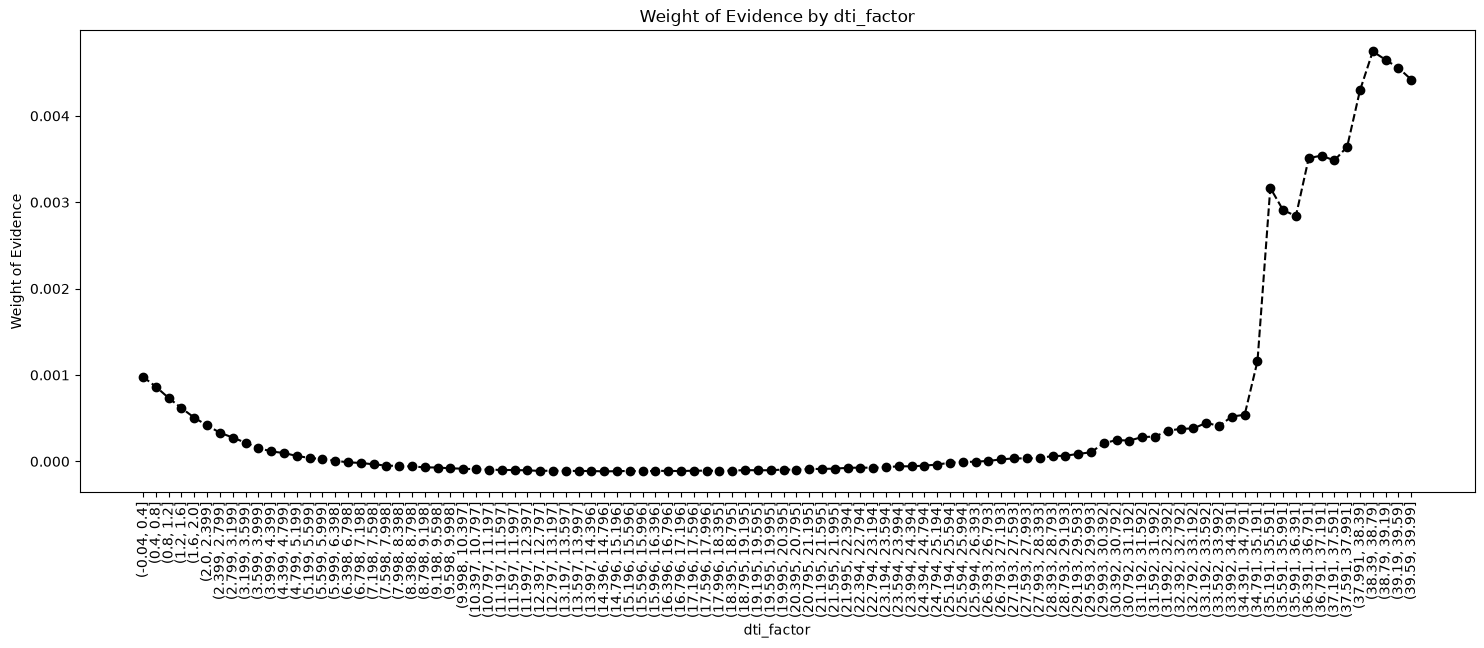

In [112]:
plot_by_woe(df_temp, 90)

In [113]:
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['dti'] <= 35, : ]

In [114]:
df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 50)

df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'dti_factor', df_targets_prepr[df_inputs_prepr_temp.index])
df_temp

,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.035, 0.7]",1694,0.892562,0.003661,1512.0,-1511.0,0.003669,0.003667,0.000540,NaN,NaN,7.033780e-09
1,"(0.7, 1.4]",2057,0.894993,0.004446,1841.0,-1840.0,0.004467,0.004465,0.000422,0.002431,1.182638e-04,7.033780e-09
2,"(1.4, 2.1]",2522,0.909199,0.005451,2293.0,-2292.0,0.005564,0.005562,0.000315,0.014206,1.071256e-04,7.033780e-09
3,"(2.1, 2.8]",3201,0.913777,0.006918,2925.0,-2924.0,0.007097,0.007096,0.000221,0.004578,9.426623e-05,7.033780e-09
4,"(2.8, 3.5]",3946,0.907501,0.008528,3581.0,-3580.0,0.008689,0.008688,0.000158,0.006276,6.264819e-05,7.033780e-09
5,"(3.5, 4.2]",4814,0.913170,0.010404,4396.0,-4395.0,0.010667,0.010665,0.000106,0.005669,5.178520e-05,7.033780e-09
6,"(4.2, 4.9]",5735,0.913862,0.012395,5241.0,-5240.0,0.012717,0.012716,0.000069,0.000692,3.668392e-05,7.033780e-09
7,"(4.9, 5.6]",6682,0.912451,0.014442,6097.0,-6096.0,0.014794,0.014793,0.000043,0.001411,2.679295e-05,7.033780e-09
8,"(5.6, 6.3]",7418,0.912780,0.016032,6771.0,-6770.0,0.016429,0.016429,0.000026,0.000328,1.632896e-05,7.033780e-09
9,"(6.3, 7.0]",8204,0.914798,0.017731,7505.0,-7504.0,0.018210,0.018210,0.000012,0.002018,1.444620e-05,7.033780e-09


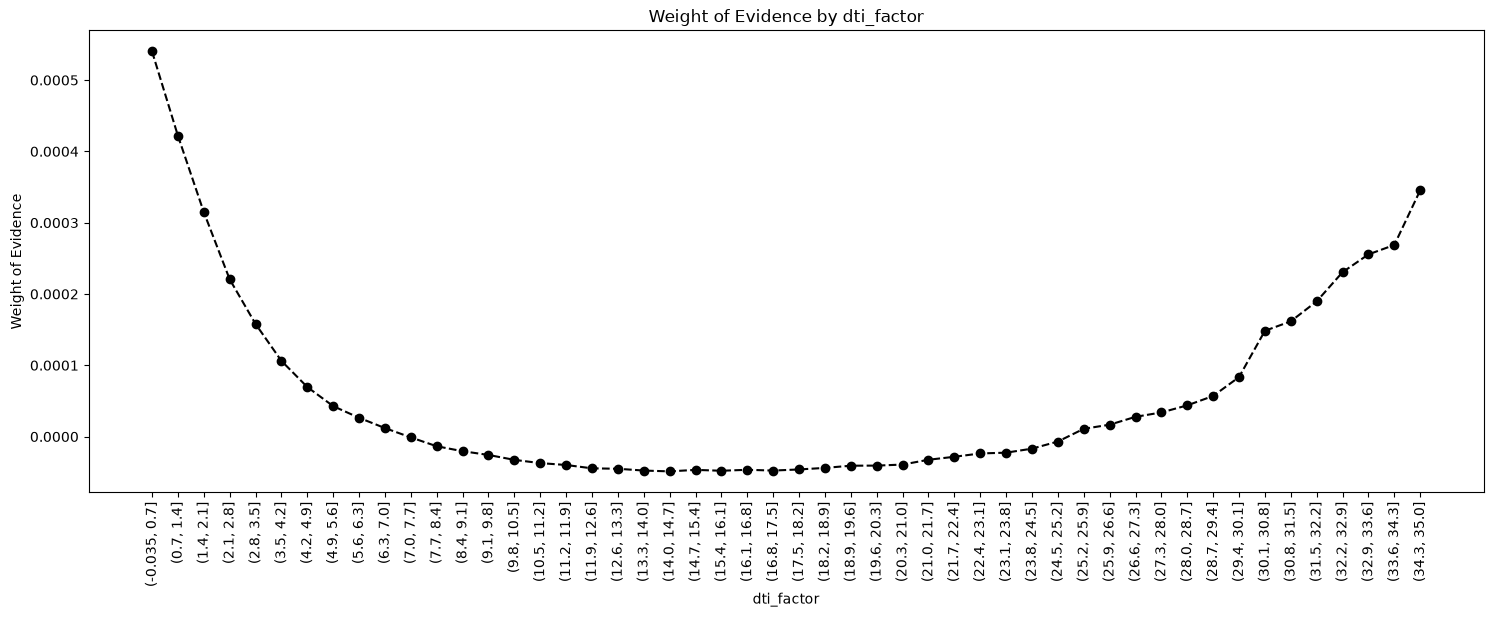

In [115]:
plot_by_woe(df_temp, 90)

In [116]:
# Categories:
df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
df_inputs_prepr['dti:3.5-7.7'] = np.where((df_inputs_prepr['dti'] > 3.5) & (df_inputs_prepr['dti'] <= 7.7), 1, 0)
df_inputs_prepr['dti:7.7-10.5'] = np.where((df_inputs_prepr['dti'] > 7.7) & (df_inputs_prepr['dti'] <= 10.5), 1, 0)
df_inputs_prepr['dti:10.5-16.1'] = np.where((df_inputs_prepr['dti'] > 10.5) & (df_inputs_prepr['dti'] <= 16.1), 1, 0)
df_inputs_prepr['dti:16.1-20.3'] = np.where((df_inputs_prepr['dti'] > 16.1) & (df_inputs_prepr['dti'] <= 20.3), 1, 0)
df_inputs_prepr['dti:20.3-21.7'] = np.where((df_inputs_prepr['dti'] > 20.3) & (df_inputs_prepr['dti'] <= 21.7), 1, 0)
df_inputs_prepr['dti:21.7-22.4'] = np.where((df_inputs_prepr['dti'] > 21.7) & (df_inputs_prepr['dti'] <= 22.4), 1, 0)
df_inputs_prepr['dti:22.4-35'] = np.where((df_inputs_prepr['dti'] > 22.4) & (df_inputs_prepr['dti'] <= 35), 1, 0)
df_inputs_prepr['dti:>35'] = np.where((df_inputs_prepr['dti'] > 35), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\284476014.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\284476014.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\284476014.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is us

#### **mths_since_last_record** column 

In [117]:
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_record'])]
#sum(loan_data_temp['mths_since_last_record'].isnull())
df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)

df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'mths_since_last_record_factor', df_targets_prepr[df_inputs_prepr_temp.index])
df_temp

C:\Users\k\AppData\Local\Temp\ipykernel_16576\2153013207.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,mths_since_last_record_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.129, 2.58]",1330,0.760150,0.021233,1011.0,-1010.0,0.018059,0.018056,1.318536e-04,NaN,NaN,-inf
1,"(2.58, 5.16]",156,0.897436,0.002491,140.0,-139.0,0.002501,0.002485,6.310734e-03,0.137286,0.006179,-inf
2,"(5.16, 7.74]",158,0.917722,0.002522,145.0,-144.0,0.002590,0.002574,6.062687e-03,0.020286,0.000248,-inf
3,"(7.74, 10.32]",306,0.915033,0.004885,280.0,-279.0,0.005001,0.004988,2.720066e-03,0.002689,0.003343,-inf
4,"(10.32, 12.9]",250,0.892000,0.003991,223.0,-222.0,0.003983,0.003969,3.636634e-03,0.023033,0.000917,-inf
5,"(12.9, 15.48]",387,0.906977,0.006178,351.0,-350.0,0.006270,0.006257,1.995313e-03,0.014977,0.001641,-inf
6,"(15.48, 18.06]",419,0.909308,0.006689,381.0,-380.0,0.006806,0.006793,1.770367e-03,0.002331,0.000225,-inf
7,"(18.06, 20.64]",308,0.931818,0.004917,287.0,-286.0,0.005126,0.005113,2.632649e-03,0.022510,0.000862,-inf
8,"(20.64, 23.22]",552,0.907609,0.008813,501.0,-500.0,0.008949,0.008939,1.140247e-03,0.024209,0.001492,-inf
9,"(23.22, 25.8]",400,0.905000,0.006386,362.0,-361.0,0.006466,0.006454,1.908498e-03,0.002609,0.000768,-inf


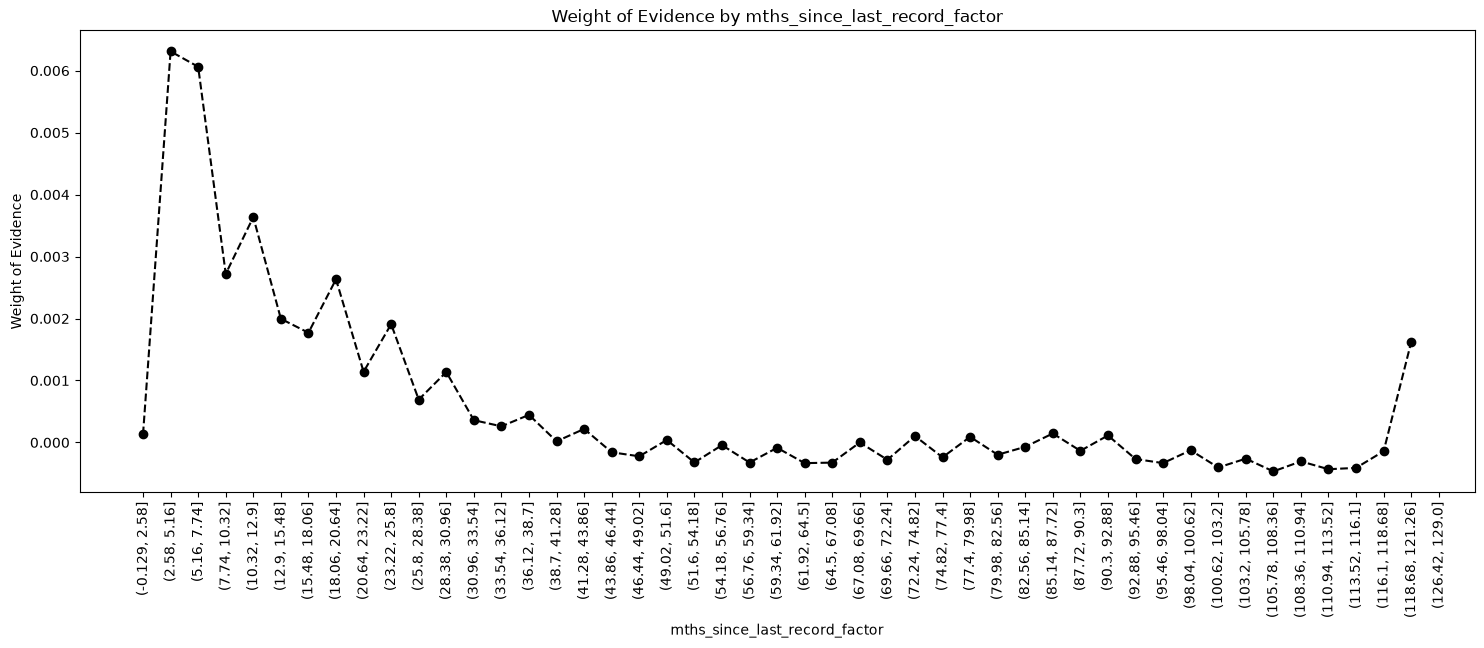

In [118]:
plot_by_woe(df_temp, 90)

In [119]:
# Categories: 'Missing', '0-2', '3-20', '21-31', '32-80', '81-86', '>86'
df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
df_inputs_prepr['mths_since_last_record:3-20'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 3) & (df_inputs_prepr['mths_since_last_record'] <= 20), 1, 0)
df_inputs_prepr['mths_since_last_record:21-31'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 21) & (df_inputs_prepr['mths_since_last_record'] <= 31), 1, 0)
df_inputs_prepr['mths_since_last_record:32-80'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 32) & (df_inputs_prepr['mths_since_last_record'] <= 80), 1, 0)
df_inputs_prepr['mths_since_last_record:81-86'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 81) & (df_inputs_prepr['mths_since_last_record'] <= 86), 1, 0)
df_inputs_prepr['mths_since_last_record:>86'] = np.where((df_inputs_prepr['mths_since_last_record'] > 86), 1, 0)

C:\Users\k\AppData\Local\Temp\ipykernel_16576\1059239224.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
C:\Users\k\AppData\Local\Temp\ipykernel_16576\1059239224.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
C:\Users\k\AppData\Local\Temp\i

## Splitting data into Train and test sets

In [120]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets.
# 80% of the data will be used for training, and 20% will be used for testing.
# random_state=42 makes the split reproducible, so we get the same split every time.
X_train, X_test, y_train, y_test = train_test_split(
    df_inputs_prepr, df_targets_prepr,
    test_size=0.2,
    random_state=42
)

In [121]:
os.getcwd()

'c:\\Users\\k\\Credit_Risk_Model'

In [123]:
X_train.to_csv("data/inputs_train.csv", index=False)
y_train.to_csv("data/target_train.csv", index=False)

X_test.to_csv("data/inputs_test.csv", index=False)
y_test.to_csv("data/target_test.csv", index=False)